## LIBRARIES

In [43]:
# system and utility libraries
import os
import json
import time
import random
import logging
import joblib
import math

# data manipulation
import numpy as np
import pandas as pd

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# geospatial visualization
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# statistical analysis and scientific computing
from scipy import stats
from scipy.stats import norm
from scipy.interpolate import griddata
from scipy.spatial import ConvexHull
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_regression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# deep learning framework
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.models import Sequential, clone_model
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout, Reshape, Flatten
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# report HTML
import base64
from io import BytesIO

# reproducibility and log configuration
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

tf.config.experimental.enable_op_determinism()

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
logging.getLogger('tensorflow').setLevel(logging.FATAL)

print("libraries loaded successfully")


libraries loaded successfully


## PREPARATION

### Vessel Data Acquisition and Feature Selection


In [44]:
input_path = r"C:\Users\siani\Desktop\DF"
vessel_names = ["ECO ADRIATICA", "ECO LIVORNO"]
datasets = {}

# define a robust physical interpolation filter for target fuel flows
def clean_flow_dropouts_interpolation(df, col):
    y = df[col].values.copy()
    
    # convert any values below 0.3 mt/h to NaN (since harbor and maneuvers are already excluded)
    df_temp = pd.Series(y)
    anom_mask = y < 0.3
    df_temp[anom_mask] = np.nan
    
    # apply linear interpolation to fill the sensor gaps and forward/backward fill the rest
    y_clean = df_temp.interpolate(method='linear').ffill().bfill().values
    return y_clean

print("loading datasets")

for name in vessel_names:
    safe_name = name.replace(" ", "_")
    file_path = os.path.join(input_path, f"refined_15min_{safe_name}.csv")
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep=',')
        df['ts'] = pd.to_datetime(df['ts'])
        df = df.sort_values('ts')
        
        # apply the new robust physical interpolation filter
        df['ep_ME_FLW_SUP_1'] = clean_flow_dropouts_interpolation(df, 'ep_ME_FLW_SUP_1')
        df['ep_ME_FLW_SUP_2'] = clean_flow_dropouts_interpolation(df, 'ep_ME_FLW_SUP_2')
        
        datasets[name] = df
        print(f"{name.lower()} loaded and physically cleaned")
    else:
        print(f"error file not found for {name.lower()}")

print("operation completed datasets ready for prediction")

navigation_vars = ['ep_SHIP_SOG_1', 'ep_SHIP_STW_1', 'ep_SHIP_DRAFTAFT_1', 'ep_SHIP_DRAFTFOR_1', 'ep_SHIP_HEAD_1', 'miglia']
power_vars = ['SHA_POW_TOT', 'DG_POW_TOT']
weather_vars = ['ep_SHIP_WSPEED_1', 'ep_WH_WAVEH_1', 'ep_WH_WAVEP_1', 'ep_WH_SWELLH_1', 'ep_WH_SWELLP_1', 'ep_WH_SPEED_1', 
                'ep_SHIP_WDIR_1', 'ep_SHIP_SEAF_1', 'ep_SHIP_SEADIR_1', 'ep_WH_DIR_1', 'ep_WH_AIRT_1']
position_vars = []
flw_vars = ['ep_ME_FLW_SUP_1', 'ep_ME_FLW_SUP_2', 'ep_DG_FLW_SUP_1', 'ep_DG_FLW_SUP_2', 'ep_DG_FLW_SUP_3']

target_vars = ['ep_ME_FLW_SUP_1', 'ep_ME_FLW_SUP_2']

required_features = navigation_vars + power_vars + weather_vars + target_vars + position_vars


loading datasets
eco adriatica loaded and physically cleaned
eco livorno loaded and physically cleaned
operation completed datasets ready for prediction


### Active Telemetry Filtering and Dataset Loading

In [45]:
def remove_sensor_faults(df):
    df_clean = df.copy()
    
    mask_dropouts = (df_clean['ep_SHIP_SOG_1'] > 8.0) & ((df_clean['ep_ME_FLW_SUP_1'] < 0.7) | (df_clean['ep_ME_FLW_SUP_2'] < 0.7))
    df_clean = df_clean[~mask_dropouts].copy()
    
    df_clean['is_stuck'] = df_clean['ep_ME_FLW_SUP_1'].diff().abs() < 1e-4
    df_temp = df_clean.copy()
    df_temp['stuck_group'] = (df_temp['is_stuck'] != df_temp['is_stuck'].shift()).cumsum()
    df_temp['stuck_duration'] = df_temp.groupby('stuck_group')['ep_ME_FLW_SUP_1'].transform('size')
    
    mask_flatlines = (
        (df_temp['stuck_duration'] >= 6) & 
        (df_temp['ep_SHIP_SOG_1'] > 5.0) & 
        (df_temp['ep_ME_FLW_SUP_1'].between(0.94, 1.05))
    )
    
    df_final = df_temp[~mask_flatlines].copy()
    df_final.drop(columns=['is_stuck', 'stuck_group', 'stuck_duration'], inplace=True, errors='ignore')
    return df_final

print("Loading and filtering datasets...")

for name in vessel_names:
    safe_name = name.replace(" ", "_")
    file_path = os.path.join(input_path, f"refined_15min_{safe_name}.csv")
    
    if os.path.exists(file_path):
        df = pd.read_csv(file_path, sep=',')
        df['ts'] = pd.to_datetime(df['ts'])
        df = df.sort_values('ts')
        
        initial_len = len(df)
        df_filtered = remove_sensor_faults(df)
        removed_rows = initial_len - len(df_filtered)
        
        datasets[name] = df_filtered
        print(f"\n{name}: {df_filtered.shape[0]} samples loaded (removed {removed_rows} telemetry sensor faults)")
    else:
        print(f" !! error: file not found for {name}")

print(f"\nOperation completed: {len(datasets)} datasets ready for prediction")


Loading and filtering datasets...

ECO ADRIATICA: 12361 samples loaded (removed 3338 telemetry sensor faults)

ECO LIVORNO: 12791 samples loaded (removed 3767 telemetry sensor faults)

Operation completed: 2 datasets ready for prediction


### ROUTE STATISTICAL SUMMARY

In [46]:
# Pre-filter diagnostic
# Minimum route density threshold: 96 samples = 24h × 4 samples/h (15-min resolution).
# Routes below this limit lack sufficient temporal coverage to produce meaningful
# LSTM sequences and are excluded to prevent the model from learning noise patterns.
THRESHOLD_INSPECT = 96

for vessel_name, df in datasets.items():
    route_counts = df.groupby('Route').size().rename('total_samples').sort_values()
    low_routes   = route_counts[route_counts < THRESHOLD_INSPECT]
    rows_lost    = low_routes.sum()

    print(f"\n{'─'*58}")
    print(f" {vessel_name}")
    print(f"{'─'*58}")
    print(f" Total routes       : {len(route_counts)}")
    print(f" Routes below {THRESHOLD_INSPECT}    : {len(low_routes)}  "
          f"({len(low_routes)/len(route_counts)*100:.1f}%)")
    print(f" Rows to be removed : {rows_lost:,}  "
          f"({rows_lost/len(df)*100:.2f}% of dataset)")

    # Full route table, ascending by sample count
    print(f"\n {'Route':<35} {'Samples':>8}  {'Flag':>10}")
    print(f" {'─'*57}")
    for route, count in route_counts.items():
        flag = "BELOW THRESHOLD" if count < THRESHOLD_INSPECT else ""
        print(f" {'→' if flag else ' '} {route:<33} {count:>8}  {flag}")

    # Per-voyage breakdown for low-density routes only
    if not low_routes.empty:
        print(f"\n Per-voyage detail for routes below threshold:")
        for route in low_routes.index:
            voyage_counts = (df[df['Route'] == route]
                             .groupby('Voyage_ID').size()
                             .rename('samples')
                             .sort_values())
            print(f"\n  Route: '{route}'  |  "
                  f"Total samples: {voyage_counts.sum()}  |  "
                  f"Voyages: {len(voyage_counts)}")
            print(f"  {'Voyage_ID':<15} {'Samples':>8}  {'~Duration (h)':>14}")
            for vid, s in voyage_counts.items():
                print(f"  {str(vid):<15} {s:>8}  {s * 15 / 60:>14.1f}")

    # Sample-count distribution across all routes to evaluate the threshold
    bins   = [0, 25, 50, 100, 250, 500, 1000, route_counts.max() + 1]
    labels = ['<25', '25-50', '50-100', '100-250', '250-500', '500-1k', '>1k']
    dist   = pd.cut(route_counts, bins=bins, labels=labels).value_counts().sort_index()
    print(f"\n Route density distribution:")
    for bucket, cnt in dist.items():
        marker = " *" if bucket in ['<25', '25-50', '50-100'] else "  "
        print(f"  {marker}{str(bucket):>8} samples : {cnt:>3} routes")
    print(f"  (* below threshold)")



──────────────────────────────────────────────────────────
 ECO ADRIATICA
──────────────────────────────────────────────────────────
 Total routes       : 42
 Routes below 96    : 20  (47.6%)
 Rows to be removed : 748  (6.05% of dataset)

 Route                                Samples        Flag
 ─────────────────────────────────────────────────────────
 → VALENCIA to LIVORNO                      3  BELOW THRESHOLD
 → LIVORNO to PIOMBINO                      5  BELOW THRESHOLD
 → SAGUNTO to CAGLIARI                      6  BELOW THRESHOLD
 → PIOMBINO to LIVORNO                      9  BELOW THRESHOLD
 → SAGUNTO to VALENCIA                     16  BELOW THRESHOLD
 → BARCELONA to PALMA DI MAIORCA           22  BELOW THRESHOLD
 → SALERNO to LIVORNO                      25  BELOW THRESHOLD
 → VALENCIA to TERRAGONA                   26  BELOW THRESHOLD
 → TERRAGONA to PALMA DI MAIORCA           26  BELOW THRESHOLD
 → SAGUNTO to BARCELONA                    26  BELOW THRESHOLD
 → PALMA DI M

### Dataset Refinement and Route filtering

In [47]:
# filtering threshold: minimum samples required per route to ensure statistical significance
MIN_SAMPLES_THRESHOLD = 96

for name, df in datasets.items():
    # step 1: calculate total data points available for each specific route
    route_counts = df.groupby('Route').size()
    
    valid_routes = route_counts[route_counts >= MIN_SAMPLES_THRESHOLD].index.tolist()
    
    # filter the dataset to retain only high-density routes
    initial_count = len(df)
    datasets[name] = df[df['Route'].isin(valid_routes)].copy()
    final_count = len(datasets[name])
    
    removed_count = initial_count - final_count
    print(f"{name}: removed {removed_count} samples from low-density routes. remaining: {final_count}")

print("\nroute filtering completed: datasets are now optimized for lstm training")


ECO ADRIATICA: removed 748 samples from low-density routes. remaining: 11613
ECO LIVORNO: removed 651 samples from low-density routes. remaining: 12140

route filtering completed: datasets are now optimized for lstm training


### Correlation Analysis


feature engineering and correlation analysis for eco adriatica
info removed constant variables: ['ep_SHIP_SEAF_1', 'ep_SHIP_SEADIR_1']
model input size: 37 features


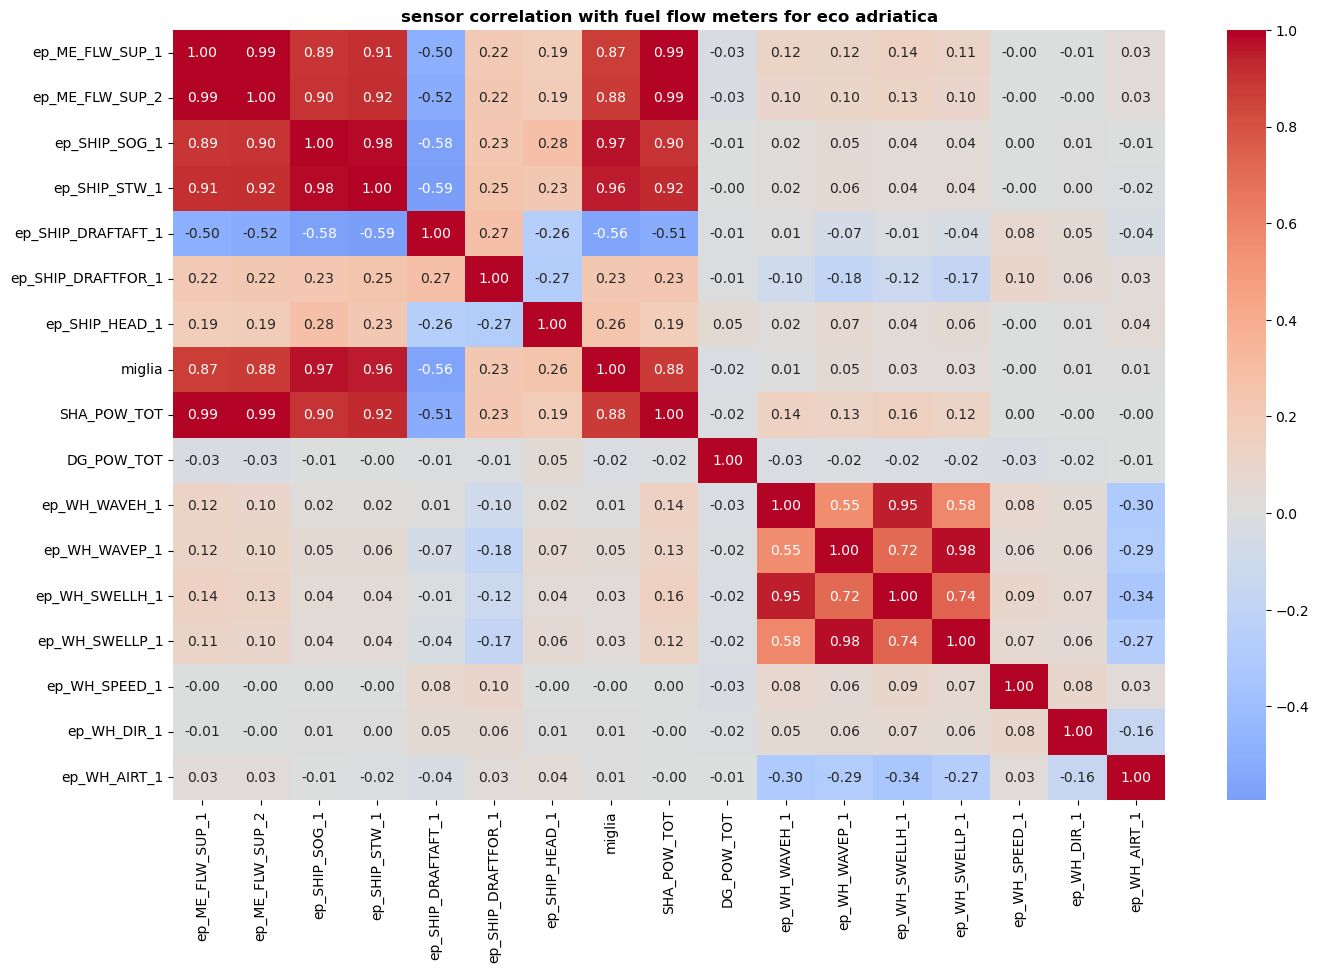


feature engineering and correlation analysis for eco livorno
model input size: 33 features


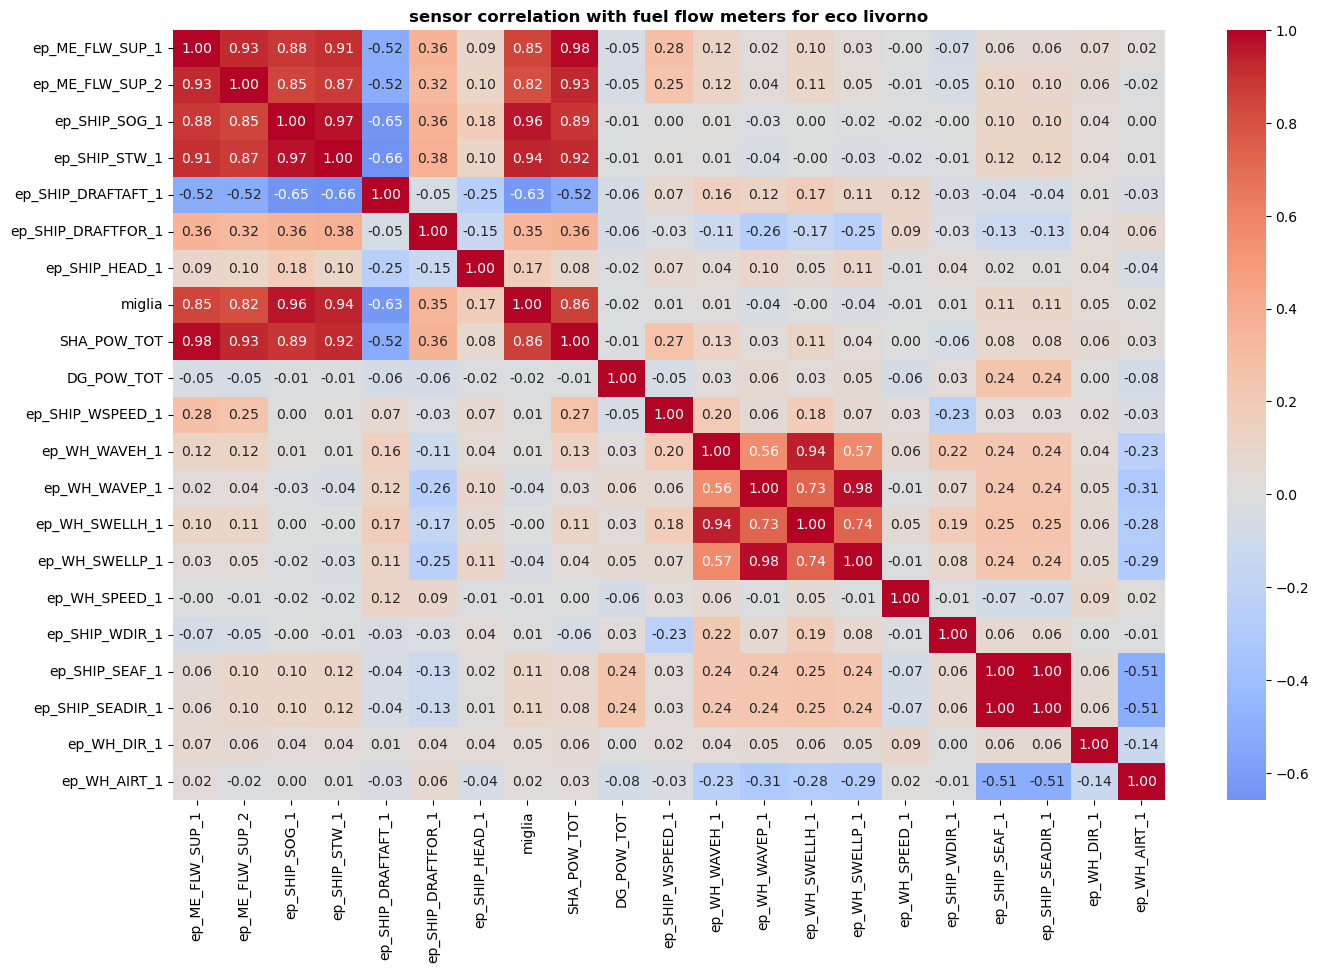

In [48]:
input_vectors = {}

for name, df in datasets.items():
    print(f"\nfeature engineering and correlation analysis for {name.lower()}")
    
    categorical_vars = ['Route', 'Cluster_Number']
    categorical_present = [v for v in categorical_vars if v in df.columns]
    
    df_encoded = pd.get_dummies(df, columns=categorical_present, prefix=categorical_present)
    datasets[name] = df_encoded
    
    all_cols = df_encoded.columns.tolist()
    present_features = [v for v in required_features if v in all_cols]
    
    dynamic_physical = [v for v in present_features if df_encoded[v].nunique() > 1]
    constant_features = [v for v in present_features if v not in dynamic_physical]
    
    if constant_features:
        print(f"info removed constant variables: {constant_features}")

    optimized_input = [v for v in dynamic_physical if v not in target_vars]
    
    one_hot_cols = [c for c in all_cols if any(c.startswith(v + "_") for v in categorical_present)]
    optimized_input.extend(one_hot_cols)
    input_vectors[name] = optimized_input
    
    print(f"model input size: {len(optimized_input)} features")
    
    analysis_vars = [t for t in target_vars if t in dynamic_physical] + [v for v in dynamic_physical if v in optimized_input and v not in target_vars]
    
    plt.figure(figsize=(16, 10))
    sns.heatmap(df_encoded[analysis_vars].corr(), annot=True, fmt=".2f", cmap='coolwarm', center=0)
    plt.title(f"sensor correlation with fuel flow meters for {name.lower()}", fontweight='bold')
    plt.show()




### Geographical Meteorological Analysis

generating geographical analysis for: wave height


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


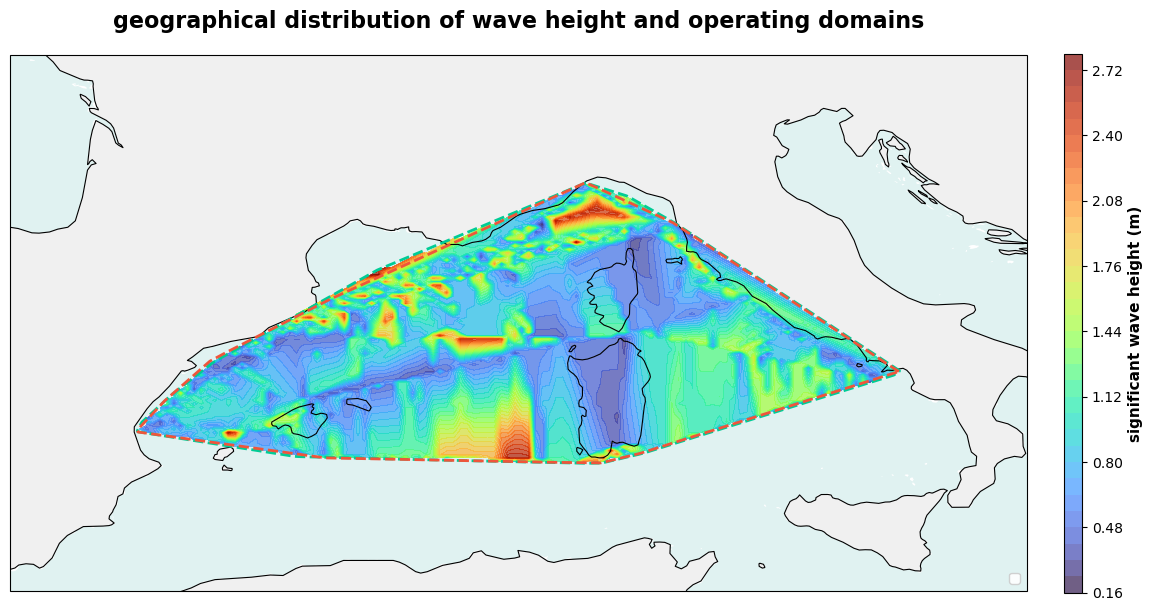

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


generating geographical analysis for: wind speed


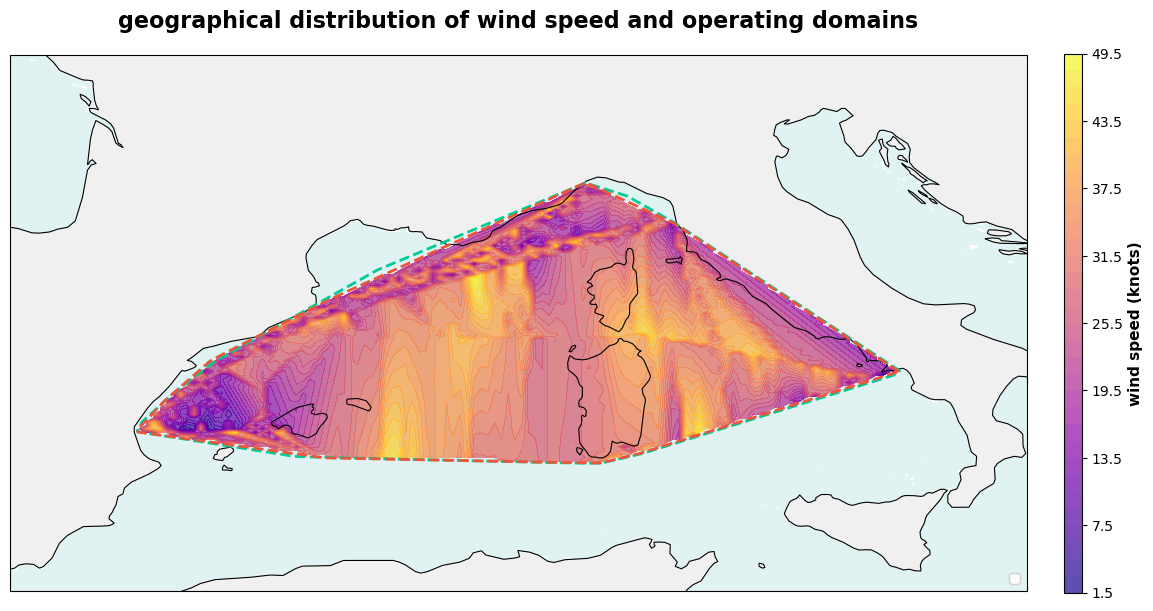

In [49]:
# variables for geographical mapping
map_variables = {
    'ep_WH_WAVEH_1': {'title': 'significant wave height (m)', 'cmap': 'turbo', 'label': 'wave height'},
    'ep_SHIP_WSPEED_1': {'title': 'wind speed (knots)', 'cmap': 'plasma', 'label': 'wind speed'}
}

# common data preparation and grid setup
df_all = pd.concat([datasets[name] for name in datasets], ignore_index=True)
margin = 2.5
lon_min, lon_max = df_all['ep_SHIP_LON_1'].min() - margin, df_all['ep_SHIP_LON_1'].max() + margin
lat_min, lat_max = df_all['ep_SHIP_LAT_1'].min() - margin, df_all['ep_SHIP_LAT_1'].max() + margin

lon_grid = np.linspace(lon_min, lon_max, 150)
lat_grid = np.linspace(lat_min, lat_max, 150)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

vessel_colors = {'ECO ADRIATICA': '#00CC96', 'ECO LIVORNO': '#EF553B'}

for var, config in map_variables.items():
    print(f"generating geographical analysis for: {config['label']}")
    
    # initialize full-page figure for each variable
    fig = plt.figure(figsize=(16, 10))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    
    # base geographical layers
    ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='#f0f0f0', zorder=1)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.8, zorder=3)
    ax.add_feature(cfeature.OCEAN, facecolor='#e0f2f1', zorder=0)

    # interpolate sensor data for current variable
    df_geo = df_all.dropna(subset=['ep_SHIP_LAT_1', 'ep_SHIP_LON_1', var])
    z_grid = griddata(
        (df_geo['ep_SHIP_LON_1'], df_geo['ep_SHIP_LAT_1']), 
        df_geo[var], 
        (lon_mesh, lat_mesh), 
        method='linear' 
    )

    # plot meteorological heatmap
    heatmap = ax.contourf(lon_mesh, lat_mesh, z_grid, levels=35, 
                         transform=ccrs.PlateCarree(), cmap=config['cmap'], alpha=0.7, zorder=2)
    
    # overlay vessel operating hulls
    for name in datasets:
        v_df = datasets[name].dropna(subset=['ep_SHIP_LAT_1', 'ep_SHIP_LON_1'])
        if len(v_df) > 3:
            coords = v_df[['ep_SHIP_LON_1', 'ep_SHIP_LAT_1']].values
            hull = ConvexHull(coords)
            perimeter = coords[hull.vertices]
            perimeter = np.append(perimeter, [perimeter[0]], axis=0)
            
            ax.plot(perimeter[:, 0], perimeter[:, 1], 
                    color=vessel_colors.get(name, 'black'), 
                    linestyle='--', linewidth=2, transform=ccrs.PlateCarree(), zorder=4)

    # finalize plot with legend and colorbar
    cbar = plt.colorbar(heatmap, orientation='vertical', pad=0.03, aspect=30, shrink=0.7)
    cbar.set_label(config['title'], fontsize=11, fontweight='bold')
    
    plt.legend(loc='lower right', frameon=True, facecolor='white', framealpha=0.9)
    plt.title(f"geographical distribution of {config['label']} and operating domains", 
              fontsize=16, pad=20, fontweight='bold')
    
    plt.show()


## LSTM TENSOR PREPARATION

In [50]:
lookback = 16          
horizon = 1           
min_trip_rows = 4    
target_features = ['ep_ME_FLW_SUP_1', 'ep_ME_FLW_SUP_2']

lstm_data = {}
vessel_scalers = {}

def create_sequences_by_trip(df, features, targets, lb, hr):
    xs, ys, ts_list = [], [], []
    for _, df_trip in df.groupby('Voyage_ID'):
        if len(df_trip) >= lb + hr:
            x_vals = df_trip[features].values
            y_vals = df_trip[targets].values
            ts_vals = pd.to_datetime(df_trip['ts']).values
            
            for i in range(len(x_vals) - lb - hr + 1):
                time_diff = (ts_vals[i + lb + hr - 1] - ts_vals[i]) / np.timedelta64(1, 'm')
                expected_diff = (lb + hr - 1) * 15
                
                if time_diff == expected_diff:
                    xs.append(x_vals[i : i + lb])
                    target_seq = y_vals[i + lb : i + lb + hr]
                    ys.append(target_seq.flatten() if hr == 1 else target_seq)
                    ts_list.append(ts_vals[i + lb])
                    
    return np.array(xs), np.array(ys), np.array(ts_list)

for name, df_raw in datasets.items():
    print(f"\npreparing tensors and temporal split for: {name}")
    df = df_raw.copy().sort_values('ts')
    input_cols = [f for f in input_vectors[name] if f in df.columns and f not in target_features]
    
    trip_counts = df.groupby('Voyage_ID').size()
    valid_trip_ids = trip_counts[trip_counts >= min_trip_rows].index.tolist()
    
    n_trips = len(valid_trip_ids)
    train_split = int(n_trips * 0.7)
    test_split = int(n_trips * 0.9)
    
    train_ids = valid_trip_ids[:train_split]
    test_ids = valid_trip_ids[train_split:test_split]
    val_ids = valid_trip_ids[test_split:]

    train_df = df[df['Voyage_ID'].isin(train_ids)].copy()
    test_df = df[df['Voyage_ID'].isin(test_ids)].copy()
    val_df = df[df['Voyage_ID'].isin(val_ids)].copy()

    def get_date_range(df_set):
        if df_set.empty: return "n/a"
        start = df_set['ts'].min().strftime('%d/%m/%Y')
        end = df_set['ts'].max().strftime('%d/%m/%Y')
        return f"{start} to {end}"

    sc_x, sc_y = MinMaxScaler(), MinMaxScaler()
    train_df[input_cols] = sc_x.fit_transform(train_df[input_cols])
    train_df[target_features] = sc_y.fit_transform(train_df[target_features])

    for d_set in [test_df, val_df]:
        if not d_set.empty:
            d_set[input_cols] = sc_x.transform(d_set[input_cols])
            d_set[target_features] = sc_y.transform(d_set[target_features])

    vessel_scalers[name] = {'scaler_x': sc_x, 'scaler_y': sc_y}

    x_train, y_train, ts_train = create_sequences_by_trip(train_df, input_cols, target_features, lookback, horizon)
    x_test, y_test, ts_test = create_sequences_by_trip(test_df, input_cols, target_features, lookback, horizon)
    x_val, y_val, ts_val = create_sequences_by_trip(val_df, input_cols, target_features, lookback, horizon)

    lstm_data[name] = {
        'x_train': x_train, 'y_train': y_train,
        'x_test': x_test, 'y_test': y_test,
        'x_val': x_val, 'y_val': y_val,
        'features_name': input_cols,
        'ts_test': ts_test
    }

    stats_data = [
        ["training", x_train.shape[0], get_date_range(train_df), len(train_ids)],
        ["test", x_test.shape[0], get_date_range(test_df), len(test_ids)],
        ["validation", x_val.shape[0], get_date_range(val_df), len(val_ids)]
    ]
    
    summary_table = pd.DataFrame(stats_data, columns=["set", "sequences", "time period", "voyage count"])
    print(summary_table.to_string(index=False))

print("\nprocessing completed with updated split and relaxed duration constraints.")



preparing tensors and temporal split for: ECO ADRIATICA
       set  sequences              time period  voyage count
  training       4189 04/04/2024 to 12/06/2025           197
      test       1130 12/06/2025 to 03/09/2025            56
validation        702 03/09/2025 to 12/12/2025            29

preparing tensors and temporal split for: ECO LIVORNO
       set  sequences              time period  voyage count
  training       3502 17/03/2024 to 29/04/2025           248
      test       1158 05/05/2025 to 26/10/2025            71
validation        363 26/10/2025 to 05/12/2025            36

processing completed with updated split and relaxed duration constraints.


In [ ]:
lookback = 16          
horizon = 1           
min_trip_rows = 4    
target_features = ['ep_ME_FLW_SUP_1', 'ep_ME_FLW_SUP_2']

lstm_data = {}
vessel_scalers = {}

def create_sequences_by_trip(df, features, targets, lb, hr):
    xs, ys = [], []
    for _, df_trip in df.groupby('Voyage_ID'):
        if len(df_trip) >= lb + hr:
            x_vals = df_trip[features].values
            y_vals = df_trip[targets].values
            ts_vals = pd.to_datetime(df_trip['ts']).values
            
            for i in range(len(x_vals) - lb - hr + 1):
                time_diff = (ts_vals[i + lb + hr - 1] - ts_vals[i]) / np.timedelta64(1, 'm')
                expected_diff = (lb + hr - 1) * 15
                
                if time_diff == expected_diff:
                    xs.append(x_vals[i : i + lb])
                    target_seq = y_vals[i + lb : i + lb + hr]
                    ys.append(target_seq.flatten() if hr == 1 else target_seq)
                    
    return np.array(xs), np.array(ys)

for name, df_raw in datasets.items():
    print(f"\npreparing tensors and temporal split for: {name}")
    df = df_raw.copy().sort_values('ts')
    input_cols = [f for f in input_vectors[name] if f in df.columns and f not in target_features]
    
    trip_counts = df.groupby('Voyage_ID').size()
    valid_trip_ids = trip_counts[trip_counts >= min_trip_rows].index.tolist()
    
    n_trips = len(valid_trip_ids)
    train_split = int(n_trips * 0.7)
    test_split = int(n_trips * 0.9)
    
    train_ids = valid_trip_ids[:train_split]
    test_ids = valid_trip_ids[train_split:test_split]
    val_ids = valid_trip_ids[test_split:]

    train_df = df[df['Voyage_ID'].isin(train_ids)].copy()
    test_df = df[df['Voyage_ID'].isin(test_ids)].copy()
    val_df = df[df['Voyage_ID'].isin(val_ids)].copy()

    def get_date_range(df_set):
        if df_set.empty: return "n/a"
        start = df_set['ts'].min().strftime('%d/%m/%Y')
        end = df_set['ts'].max().strftime('%d/%m/%Y')
        return f"{start} to {end}"

    sc_x, sc_y = MinMaxScaler(), MinMaxScaler()
    train_df[input_cols] = sc_x.fit_transform(train_df[input_cols])
    train_df[target_features] = sc_y.fit_transform(train_df[target_features])

    for d_set in [test_df, val_df]:
        if not d_set.empty:
            d_set[input_cols] = sc_x.transform(d_set[input_cols])
            d_set[target_features] = sc_y.transform(d_set[target_features])

    vessel_scalers[name] = {'scaler_x': sc_x, 'scaler_y': sc_y}

    x_train, y_train = create_sequences_by_trip(train_df, input_cols, target_features, lookback, horizon)
    x_test, y_test = create_sequences_by_trip(test_df, input_cols, target_features, lookback, horizon)
    x_val, y_val = create_sequences_by_trip(val_df, input_cols, target_features, lookback, horizon)

    lstm_data[name] = {
        'x_train': x_train, 'y_train': y_train,
        'x_test': x_test, 'y_test': y_test,
        'x_val': x_val, 'y_val': y_val,
        'features_name': input_cols
    }

    stats_data = [
        ["training", x_train.shape[0], get_date_range(train_df), len(train_ids)],
        ["test", x_test.shape[0], get_date_range(test_df), len(test_ids)],
        ["validation", x_val.shape[0], get_date_range(val_df), len(val_ids)]
    ]
    
    summary_table = pd.DataFrame(stats_data, columns=["set", "sequences", "time period", "voyage count"])
    print(summary_table.to_string(index=False))

print("\nprocessing completed with updated split and relaxed duration constraints.")


## HYPERPARAMETER OPTIMIZATION: IMPROVED GREY WOLF OPTIMIZER

### ECO Livorno

In [ ]:
class GeneticAlgorithmOptimizer:
    def __init__(self, pop_size=10, n_gen=5, p_mut=0.1, p_cross=0.8):
        self.pop_size = pop_size
        self.n_gen = n_gen
        self.p_mut = p_mut
        self.p_cross = p_cross
        # chromosome mapped to 4 dimensions to match igwo parameter space: [units, lr, bs, dr]
        self.lb = np.array([64, 0.0005, 16, 0.1])
        self.ub = np.array([256, 0.005, 64, 0.4]) 
        self.n_dim = 4

    def _fitness_function(self, params, x_train_opt, y_train_opt):
        u, lr, bs, dr = int(params[0]), params[1], int(params[2]), params[3]
        n_steps, n_feat = x_train_opt.shape[1], x_train_opt.shape[2]
        n_out = y_train_opt.shape[1]
        start_time = time.time()
        
        # default activation tanh is implicitly used to enforce cudnn execution
        model = Sequential([
            Input(shape=(n_steps, n_feat)),
            LSTM(u, return_sequences=True),
            Dropout(dr),
            LSTM(int(u/2)),
            Dropout(dr),
            Dense(16, activation='relu'),
            Dense(n_out, activation='linear')
        ])
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
        stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
        hist = model.fit(
            x_train_opt, y_train_opt, 
            validation_split=0.2, epochs=10, 
            batch_size=bs, callbacks=[stop], verbose=0
        )
        
        val_loss = min(hist.history['val_loss'])
        comp_efficiency = (time.time() - start_time) / 100 
        mem_usage = model.count_params() / 1000000 
        total_fitness = val_loss + (0.1 * comp_efficiency) + (0.1 * mem_usage)
        K.clear_session() 
        return total_fitness

    def _initialize_population(self):
        return np.random.uniform(self.lb, self.ub, (self.pop_size, self.n_dim))

    def _selection(self, population, fitness):
        idx = np.random.choice(range(len(population)), 3)
        tournament_fitness = [fitness[i] for i in idx]
        winner_idx = idx[np.argmin(tournament_fitness)]
        return population[winner_idx]

    def _crossover(self, parent1, parent2):
        if np.random.rand() < self.p_cross:
            alpha = np.random.rand()
            child1 = alpha * parent1 + (1 - alpha) * parent2
            child2 = alpha * parent2 + (1 - alpha) * parent1
            return child1, child2
        return parent1.copy(), parent2.copy()

    def _mutate(self, individual):
        for i in range(self.n_dim):
            if np.random.rand() < self.p_mut:
                scale = (self.ub[i] - self.lb[i]) * 0.1
                individual[i] += np.random.normal(0, scale)
        return np.clip(individual, self.lb, self.ub)

    def optimize(self, x_tr, y_tr):
        population = self._initialize_population()
        best_individual, best_score = None, float('inf')
        for gen in range(self.n_gen):
            fitness = []
            for i in range(self.pop_size):
                # print triggers instantly at the start of each individual evaluation loop
                print(f"gen {gen+1}/{self.n_gen} individual {i+1}/{self.pop_size}", flush=True)
                score = self._fitness_function(population[i], x_tr, y_tr)
                fitness.append(score)
                if score < best_score:
                    best_score, best_individual = score, population[i].copy()
            # print outputs the tracking fitness score at the end of the current generation loop
            print(f"gen {gen+1}/{self.n_gen} best fitness {best_score:.6f}", flush=True)
            new_population = [best_individual.copy()] 
            while len(new_population) < self.pop_size:
                p1, p2 = self._selection(population, fitness), self._selection(population, fitness)
                c1, c2 = self._crossover(p1, p2)
                new_population.extend([self._mutate(c1), self._mutate(c2)])
            population = np.array(new_population[:self.pop_size])
        return best_individual

# ga optimization eco adriatica
TARGET_VESSEL   = "ECO LIVORNO"
population_size = 20  
n_generations   = 10   
SUBSAMPLE_RATIO = 1.0

name        = TARGET_VESSEL
safe_name   = name.replace(' ', '_')
output_path = f"GA_opt_params_{safe_name}.json"



# data pipeline and subsampling
df_raw         = datasets[name]
voyages        = df_raw['Voyage_ID'].unique()
sample_voyages = np.random.choice(voyages, size=int(len(voyages) * SUBSAMPLE_RATIO), replace=False)
df_sample      = df_raw[df_raw['Voyage_ID'].isin(sample_voyages)].sort_values('ts')

n_voyages     = df_sample['Voyage_ID'].nunique()
feats         = lstm_data[name]['features_name']
x_opt, y_opt  = create_sequences_by_trip(df_sample, feats, target_vars, lookback, horizon)
x_opt, y_opt  = x_opt.astype('float32'), y_opt.astype('float32')

if len(x_opt) == 0:
    pass
else:
    ga              = GeneticAlgorithmOptimizer(pop_size=population_size, n_gen=n_generations)
    best_chromosome = ga.optimize(x_opt, y_opt)

    # serialization dictionary aligned to match original igwo format schema
    final_params = {
        "vessel_name":     name,
        "lstm_units":      int(best_chromosome[0]),
        "learning_rate":   float(best_chromosome[1]),
        "batch_size":      int(best_chromosome[2]),
        "dropout_rate":    float(best_chromosome[3]),
        "lookback":        lookback,
        "features_count":  len(feats)
        }

    with open(output_path, 'w') as f:
        json.dump(final_params, f, indent=4)

### ECO Adriatica

In [ ]:
class GeneticAlgorithmOptimizer:
    def __init__(self, pop_size=10, n_gen=5, p_mut=0.1, p_cross=0.8):
        self.pop_size = pop_size
        self.n_gen = n_gen
        self.p_mut = p_mut
        self.p_cross = p_cross
        # chromosome mapped to 4 dimensions to match igwo parameter space: [units, lr, bs, dr]
        self.lb = np.array([64, 0.0005, 16, 0.1])
        self.ub = np.array([256, 0.005, 64, 0.4]) 
        self.n_dim = 4

    def _fitness_function(self, params, x_train_opt, y_train_opt):
        u, lr, bs, dr = int(params[0]), params[1], int(params[2]), params[3]
        n_steps, n_feat = x_train_opt.shape[1], x_train_opt.shape[2]
        n_out = y_train_opt.shape[1]
        start_time = time.time()
        
        # default activation tanh is implicitly used to enforce cudnn execution
        model = Sequential([
            Input(shape=(n_steps, n_feat)),
            LSTM(u, return_sequences=True),
            Dropout(dr),
            LSTM(int(u/2)),
            Dropout(dr),
            Dense(16, activation='relu'),
            Dense(n_out, activation='linear')
        ])
        model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
        stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)
        hist = model.fit(
            x_train_opt, y_train_opt, 
            validation_split=0.2, epochs=10, 
            batch_size=bs, callbacks=[stop], verbose=0
        )
        
        val_loss = min(hist.history['val_loss'])
        comp_efficiency = (time.time() - start_time) / 100 
        mem_usage = model.count_params() / 1000000 
        total_fitness = val_loss + (0.1 * comp_efficiency) + (0.1 * mem_usage)
        K.clear_session() 
        return total_fitness

    def _initialize_population(self):
        return np.random.uniform(self.lb, self.ub, (self.pop_size, self.n_dim))

    def _selection(self, population, fitness):
        idx = np.random.choice(range(len(population)), 3)
        tournament_fitness = [fitness[i] for i in idx]
        winner_idx = idx[np.argmin(tournament_fitness)]
        return population[winner_idx]

    def _crossover(self, parent1, parent2):
        if np.random.rand() < self.p_cross:
            alpha = np.random.rand()
            child1 = alpha * parent1 + (1 - alpha) * parent2
            child2 = alpha * parent2 + (1 - alpha) * parent1
            return child1, child2
        return parent1.copy(), parent2.copy()

    def _mutate(self, individual):
        for i in range(self.n_dim):
            if np.random.rand() < self.p_mut:
                scale = (self.ub[i] - self.lb[i]) * 0.1
                individual[i] += np.random.normal(0, scale)
        return np.clip(individual, self.lb, self.ub)

    def optimize(self, x_tr, y_tr):
        population = self._initialize_population()
        best_individual, best_score = None, float('inf')
        for gen in range(self.n_gen):
            fitness = []
            for i in range(self.pop_size):
                # print triggers instantly at the start of each individual evaluation loop
                print(f"gen {gen+1}/{self.n_gen} individual {i+1}/{self.pop_size}", flush=True)
                score = self._fitness_function(population[i], x_tr, y_tr)
                fitness.append(score)
                if score < best_score:
                    best_score, best_individual = score, population[i].copy()
            # print outputs the tracking fitness score at the end of the current generation loop
            print(f"gen {gen+1}/{self.n_gen} best fitness {best_score:.6f}", flush=True)
            new_population = [best_individual.copy()] 
            while len(new_population) < self.pop_size:
                p1, p2 = self._selection(population, fitness), self._selection(population, fitness)
                c1, c2 = self._crossover(p1, p2)
                new_population.extend([self._mutate(c1), self._mutate(c2)])
            population = np.array(new_population[:self.pop_size])
        return best_individual

# ga optimization eco adriatica
TARGET_VESSEL   = "ECO ADRIATICA"
population_size = 20  
n_generations   = 10   
SUBSAMPLE_RATIO = 1.0

name        = TARGET_VESSEL
safe_name   = name.replace(' ', '_')
output_path = f"GA_opt_params_{safe_name}.json"



# data pipeline and subsampling
df_raw         = datasets[name]
voyages        = df_raw['Voyage_ID'].unique()
sample_voyages = np.random.choice(voyages, size=int(len(voyages) * SUBSAMPLE_RATIO), replace=False)
df_sample      = df_raw[df_raw['Voyage_ID'].isin(sample_voyages)].sort_values('ts')

n_voyages     = df_sample['Voyage_ID'].nunique()
feats         = lstm_data[name]['features_name']
x_opt, y_opt  = create_sequences_by_trip(df_sample, feats, target_vars, lookback, horizon)
x_opt, y_opt  = x_opt.astype('float32'), y_opt.astype('float32')

if len(x_opt) == 0:
    pass
else:
    ga              = GeneticAlgorithmOptimizer(pop_size=population_size, n_gen=n_generations)
    best_chromosome = ga.optimize(x_opt, y_opt)

    # serialization dictionary aligned to match original igwo format schema
    final_params = {
        "vessel_name":     name,
        "lstm_units":      int(best_chromosome[0]),
        "learning_rate":   float(best_chromosome[1]),
        "batch_size":      int(best_chromosome[2]),
        "dropout_rate":    float(best_chromosome[3]),
        "lookback":        lookback,
        "features_count":  len(feats)
        }

    with open(output_path, 'w') as f:
        json.dump(final_params, f, indent=4)

## LAYER LSTM

### ECO Adriatica


building and training base model for eco adriatica
optimal parameters loaded from GA_opt_params_ECO_ADRIATICA.json: units=101, lr=0.00133, batch=41, dropout=0.32
starting training for eco adriatica on 4189 sequences
Epoch 1/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0098 - mae: 0.0993 - val_loss: 0.0044 - val_mae: 0.0744
Epoch 2/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0043 - mae: 0.0699 - val_loss: 0.0025 - val_mae: 0.0519
Epoch 3/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 0.0038 - mae: 0.0643 - val_loss: 0.0031 - val_mae: 0.0608
Epoch 4/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0028 - mae: 0.0543 - val_loss: 0.0020 - val_mae: 0.0466
Epoch 5/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0029 - mae: 0.0556 - val_loss: 0.0023 - val_mae: 0.0520
Epoch 6/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0025 - mae: 0.0511 - val_loss: 0.0022 - val_mae: 0.0493
Epoch 7/100
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0

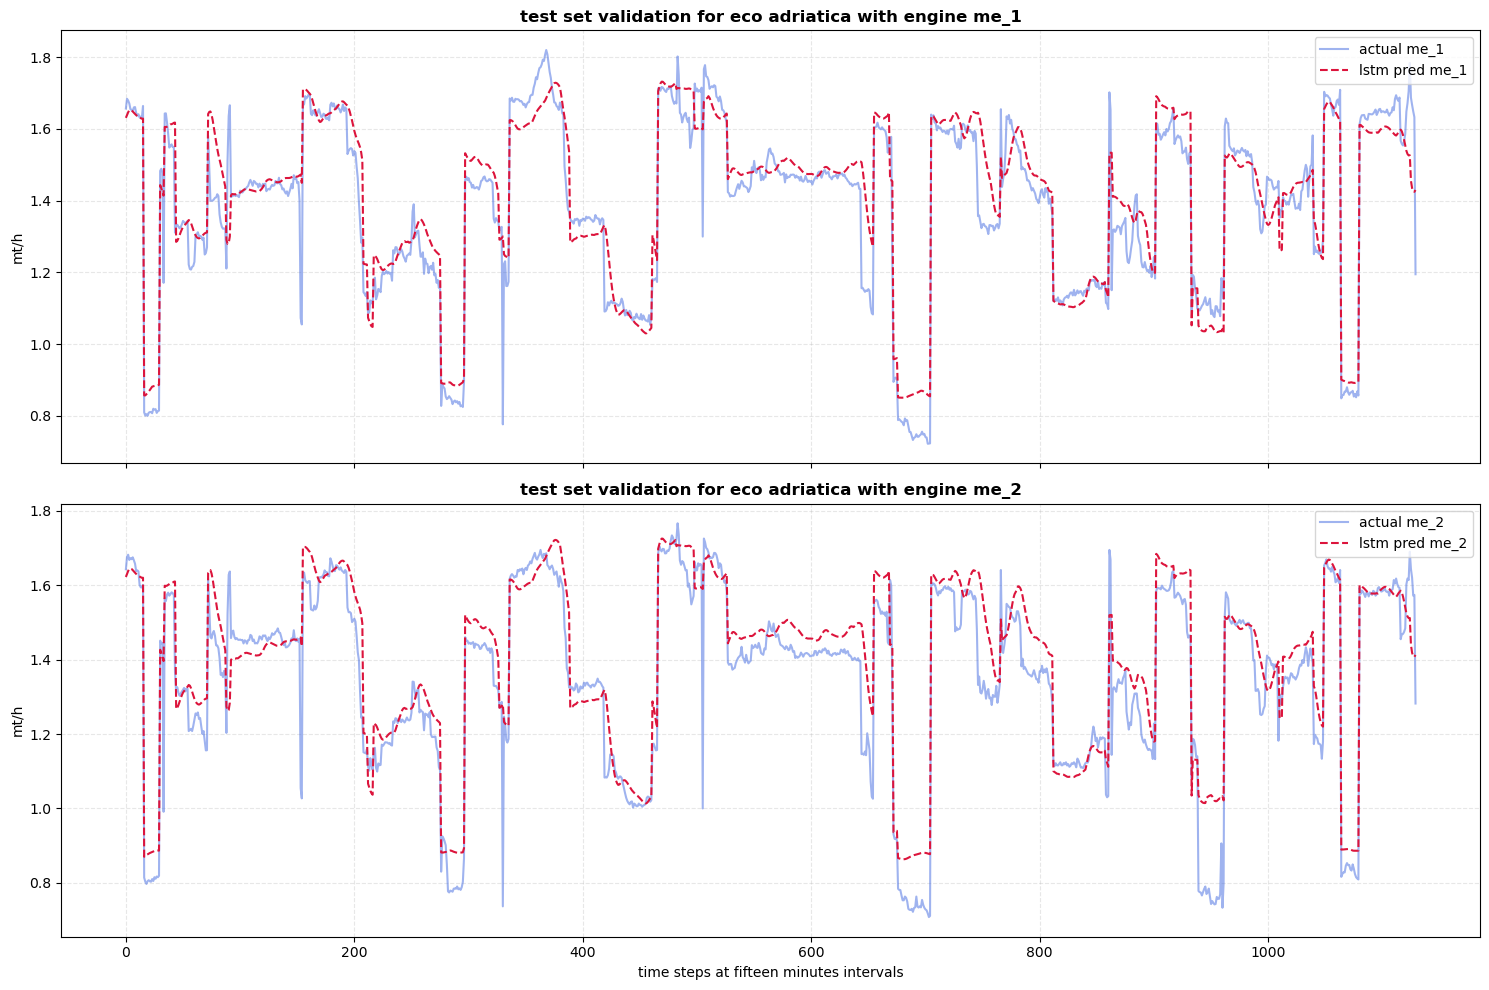

In [51]:
TARGET_VESSEL = "ECO ADRIATICA"

if 'results_storage' not in globals():
    results_storage = {}

for name in [TARGET_VESSEL]:
    if name not in lstm_data: 
        print(f"warning: {name} is not present in lstm_data skipping computation")
        continue
    
    print(f"\nbuilding and training base model for {name.lower()}")
    
    d = lstm_data[name]
    x_tr, y_tr = d['x_train'], d['y_train']
    x_vl, y_vl = d['x_val'], d['y_val']
    x_ts, y_ts = d['x_test'], d['y_test']
    
    n_outputs = y_tr.shape[1] 
    
    param_file = f"GA_opt_params_{name.replace(' ', '_')}.json"

    if os.path.exists(param_file):
        with open(param_file, "r") as f:
            p = json.load(f)
        u, lr, bs, dr = p["lstm_units"], p["learning_rate"], p["batch_size"], p["dropout_rate"]
        print(f"optimal parameters loaded from {param_file}: units={u}, lr={lr:.5f}, batch={bs}, dropout={dr:.2f}")
    else:
        print(f"optimization parameters not found at {param_file} using default configuration")
        u, lr, bs, dr = 64, 0.001, 32, 0.2

    model = Sequential([
        Input(shape=(x_tr.shape[1], x_tr.shape[2])),
        LSTM(u, return_sequences=True, activation='tanh'),
        Dropout(dr),
        LSTM(int(u/2), activation='tanh'),
        Dropout(dr),
        Dense(16, activation='relu'),
        Dense(n_outputs, activation='linear')
    ])

    model.compile(optimizer=Adam(learning_rate=lr), loss='huber', metrics=['mae'])

    print(f"starting training for {name.lower()} on {len(x_tr)} sequences")
    stop = EarlyStopping(monitor='val_loss', patience=55, restore_best_weights=True)

    history = model.fit(
        x_tr, y_tr,
        validation_data=(x_vl, y_vl),
        epochs=100,
        batch_size=bs,
        callbacks=[stop],
        verbose=1
    )

    pred_scaled = model.predict(x_ts)
    scaler_y = vessel_scalers[name]['scaler_x'] if 'scaler_y' not in vessel_scalers[name] else vessel_scalers[name]['scaler_y']
    
    pred_real = scaler_y.inverse_transform(pred_scaled)
    real_real = scaler_y.inverse_transform(y_ts)

    results_storage[name] = {
        'real': real_real, 
        'pred': pred_real,
        'history': history.history
    }
    
    model_save_path = f"model_{name.replace(' ', '_')}.keras"
    model.save(model_save_path)
    print(f"model successfully saved to {model_save_path}")

performance_report = []
for name in [TARGET_VESSEL]:
    if name not in results_storage:
        continue
        
    real = results_storage[name]['real']
    pred = results_storage[name]['pred']
    
    for i, target_col in enumerate(target_vars):
        if i >= real.shape[1]: 
            break
        
        r_vals = real[:, i]
        p_vals = pred[:, i]
        
        mae = mean_absolute_error(r_vals, p_vals)
        mse = mean_squared_error(r_vals, p_vals)
        r2 = r2_score(r_vals, p_vals)
        
        mask = r_vals > 0.5 
        mape = np.mean(np.abs((r_vals[mask] - p_vals[mask]) / r_vals[mask])) * 100 if any(mask) else 0
        
        performance_report.append({
            'vessel': name,
            'engine': target_col.replace('ep_', '').replace('_FLW_SUP', ''),
            'mae (mt/h)': round(mae, 3),
            'mse (mt/h)^2': round(mse, 6),
            'r2 score': round(r2, 4),
            'mape (%)': round(mape, 2)
        })

if performance_report:
    print("\n" + "="*85)
    print(f"final performance audit for {TARGET_VESSEL.lower()} engine analytics")
    print("="*85)
    df_perf = pd.DataFrame(performance_report)
    print(df_perf.to_string(index=False))
    print("="*85)
    
    csv_filename = f"performance_{TARGET_VESSEL.replace(' ', '_')}.csv"
    df_perf.to_csv(csv_filename, index=False)
    print(f"saved performance metrics to {csv_filename}")

for name in [TARGET_VESSEL]:
    if name not in results_storage: 
        continue
        
    real = results_storage[name]['real']
    pred = results_storage[name]['pred']
    
    n_engines = real.shape[1]
    fig, axes = plt.subplots(n_engines, 1, figsize=(15, 5 * n_engines), sharex=True)
    
    if n_engines == 1: 
        axes = [axes]
    
    for i in range(n_engines):
        engine_label = target_vars[i].replace('ep_', '').replace('_FLW_SUP', '')
        
        axes[i].plot(real[:, i], color='royalblue', label=f'actual {engine_label.lower()}', alpha=0.5)
        axes[i].plot(pred[:, i], color='crimson', label=f'lstm pred {engine_label.lower()}', linestyle='--', lw=1.5)
        
        axes[i].set_title(f"test set validation for {name.lower()} with engine {engine_label.lower()}", fontweight='bold')
        axes[i].set_ylabel("mt/h")
        axes[i].legend(loc='upper right')
        axes[i].grid(True, linestyle='--', alpha=0.3)
    
    axes[-1].set_xlabel("time steps at fifteen minutes intervals")
    plt.tight_layout()
    
    plot_filename = f"validation_plot_{name.replace(' ', '_')}.png"
    plt.savefig(plot_filename, dpi=300)
    print(f"saved validation plot to {plot_filename}")
    
    plt.show()


### ECO Livorno


building and training model for eco livorno
optimal parameters loaded: units=108, lr=0.00090, batch=44, dropout=0.28
starting training for eco livorno on 3502 sequences
Epoch 1/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 0.0302 - mae: 0.1831 - val_loss: 0.0080 - val_mae: 0.1008
Epoch 2/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0086 - mae: 0.1011 - val_loss: 0.0056 - val_mae: 0.0842
Epoch 3/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0072 - mae: 0.0913 - val_loss: 0.0054 - val_mae: 0.0805
Epoch 4/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0066 - mae: 0.0864 - val_loss: 0.0060 - val_mae: 0.0843
Epoch 5/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0061 - mae: 0.0826 - val_loss: 0.0047 - val_mae: 0.0764
Epoch 6/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0056 - mae: 0.0795 - val_loss: 0.0045 - val_mae: 0.0755
Epoch 7/100
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0055 - mae: 0.0778 - val_loss: 0.0043 - val_mae: 0.0726
Epoc

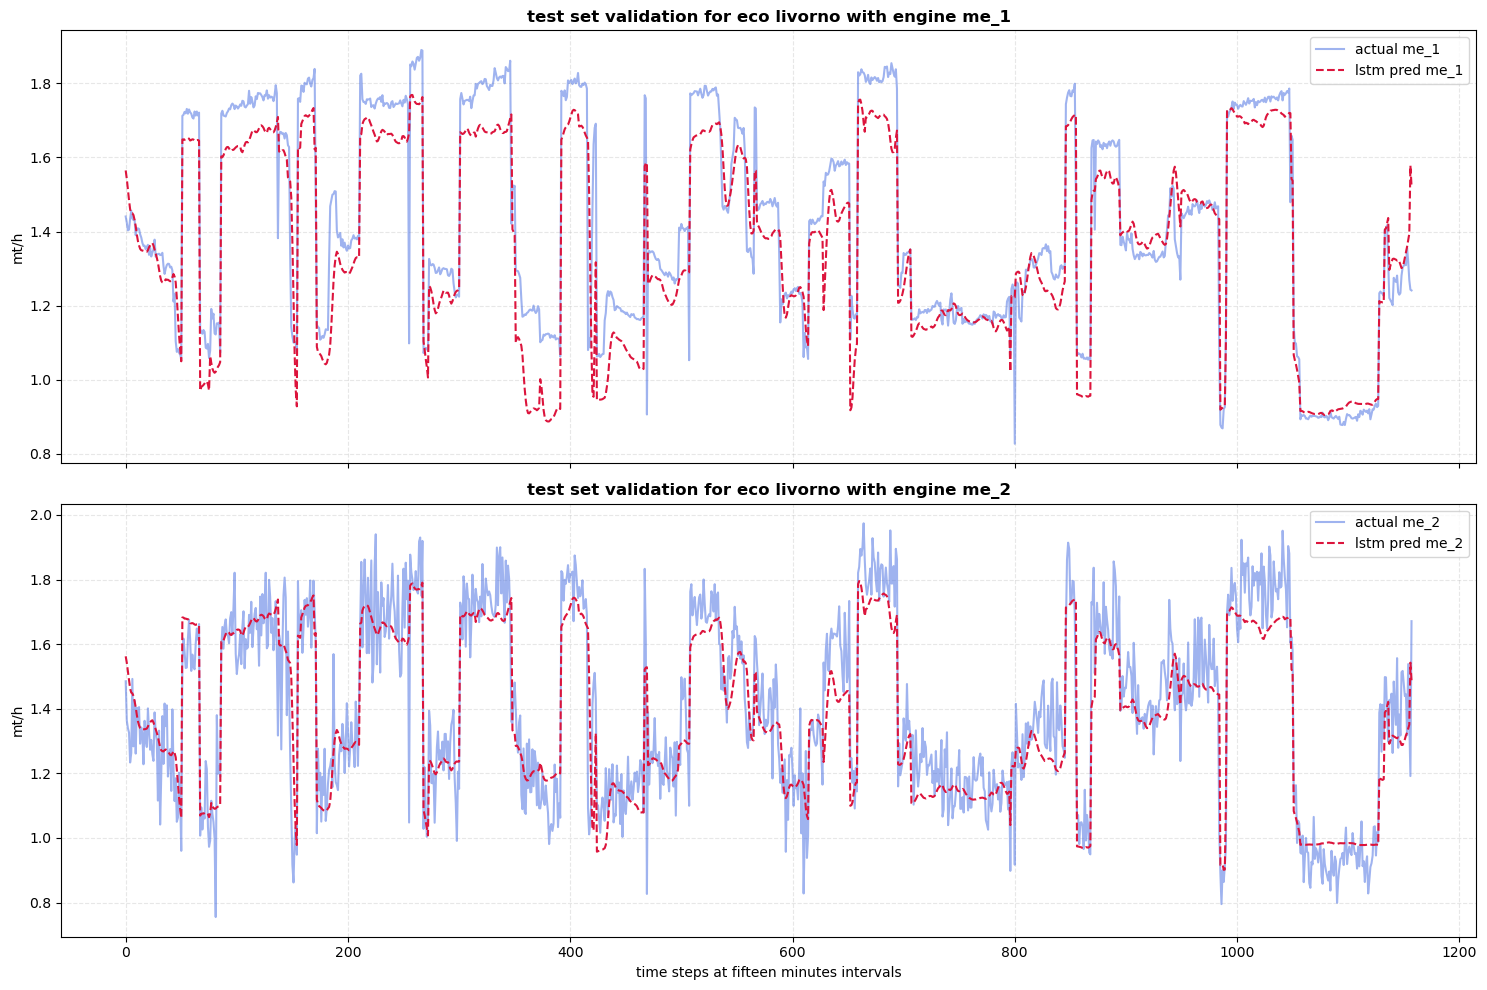

In [52]:
TARGET_VESSEL = "ECO LIVORNO"

if 'results_storage' not in globals():
    results_storage = {}

for name in [TARGET_VESSEL]:
    if name not in lstm_data: 
        print(f"warning: {name} is not present in lstm_data skipping computation")
        continue
    
    print(f"\nbuilding and training model for {name.lower()}")
    
    d = lstm_data[name]
    x_tr, y_tr = d['x_train'], d['y_train']
    x_vl, y_vl = d['x_val'], d['y_val']
    x_ts, y_ts = d['x_test'], d['y_test']
    
    n_outputs = y_tr.shape[1] 
    
    param_file = f"GA_opt_params_{name.replace(' ', '_')}.json"
    
    if os.path.exists(param_file):
        with open(param_file, "r") as f:
            p = json.load(f)
        u, lr, bs, dr = p["lstm_units"], p["learning_rate"], p["batch_size"], p["dropout_rate"]
        print(f"optimal parameters loaded: units={u}, lr={lr:.5f}, batch={bs}, dropout={dr:.2f}")
    else:
        print(f"optimization parameters not found at {param_file} using default configuration")
        u, lr, bs, dr = 64, 0.001, 32, 0.2

    model = Sequential([
        Input(shape=(x_tr.shape[1], x_tr.shape[2])),
        LSTM(u, return_sequences=True, activation='tanh'),
        Dropout(dr),
        LSTM(int(u/2), activation='tanh'),
        Dropout(dr),
        Dense(16, activation='relu'),
        Dense(n_outputs, activation='linear')
    ])

    model.compile(optimizer=Adam(learning_rate=lr), loss='huber', metrics=['mae'])

    print(f"starting training for {name.lower()} on {len(x_tr)} sequences")
    stop = EarlyStopping(monitor='val_loss', patience=55, restore_best_weights=True)
    
    history = model.fit(
        x_tr, y_tr,
        validation_data=(x_vl, y_vl),
        epochs=100,
        batch_size=bs,
        callbacks=[stop],
        verbose=1
    )

    pred_scaled = model.predict(x_ts)
    scaler_y = vessel_scalers[name]['scaler_x'] if 'scaler_y' not in vessel_scalers[name] else vessel_scalers[name]['scaler_y']
    
    pred_real = scaler_y.inverse_transform(pred_scaled)
    real_real = scaler_y.inverse_transform(y_ts)

    results_storage[name] = {
        'real': real_real, 
        'pred': pred_real,
        'history': history.history
    }
    
    model_save_path = f"model_{name.replace(' ', '_')}.keras"
    model.save(model_save_path)
    print(f"model successfully saved to {model_save_path}")

performance_report = []
for name in [TARGET_VESSEL]:
    if name not in results_storage:
        continue
        
    real = results_storage[name]['real']
    pred = results_storage[name]['pred']
    
    for i, target_col in enumerate(target_vars):
        if i >= real.shape[1]: 
            break
        
        r_vals = real[:, i]
        p_vals = pred[:, i]
        
        mae = mean_absolute_error(r_vals, p_vals)
        mse = mean_squared_error(r_vals, p_vals)
        r2 = r2_score(r_vals, p_vals)
        
        mask = r_vals > 0.5 
        mape = np.mean(np.abs((r_vals[mask] - p_vals[mask]) / r_vals[mask])) * 100 if any(mask) else 0
        
        performance_report.append({
            'vessel': name,
            'engine': target_col.replace('ep_', '').replace('_FLW_SUP', ''),
            'mae (mt/h)': round(mae, 3),
            'mse (mt/h)^2': round(mse, 6),
            'r2 score': round(r2, 4),
            'mape (%)': round(mape, 2)
        })

if performance_report:
    print("\n" + "="*85)
    print(f"final performance audit for {TARGET_VESSEL.lower()} engine analytics")
    print("="*85)
    df_perf = pd.DataFrame(performance_report)
    print(df_perf.to_string(index=False))
    print("="*85)
    
    csv_filename = f"performance_{TARGET_VESSEL.replace(' ', '_')}.csv"
    df_perf.to_csv(csv_filename, index=False)
    print(f"saved performance metrics to {csv_filename}")

for name in [TARGET_VESSEL]:
    if name not in results_storage: 
        continue
        
    real = results_storage[name]['real']
    pred = results_storage[name]['pred']
    
    n_engines = real.shape[1]
    fig, axes = plt.subplots(n_engines, 1, figsize=(15, 5 * n_engines), sharex=True)
    
    if n_engines == 1: 
        axes = [axes]
    
    for i in range(n_engines):
        engine_label = target_vars[i].replace('ep_', '').replace('_FLW_SUP', '')
        
        axes[i].plot(real[:, i], color='royalblue', label=f'actual {engine_label.lower()}', alpha=0.5)
        axes[i].plot(pred[:, i], color='crimson', label=f'lstm pred {engine_label.lower()}', linestyle='--', lw=1.5)
        
        axes[i].set_title(f"test set validation for {name.lower()} with engine {engine_label.lower()}", fontweight='bold')
        axes[i].set_ylabel("mt/h")
        axes[i].legend(loc='upper right')
        axes[i].grid(True, linestyle='--', alpha=0.3)
    
    axes[-1].set_xlabel("time steps at fifteen minutes intervals")
    plt.tight_layout()
    
    plot_filename = f"validation_plot_{name.replace(' ', '_')}.png"
    plt.savefig(plot_filename, dpi=300)
    print(f"saved validation plot to {plot_filename}")
    
    plt.show()


### Validazione con Metodo Monte Carlo

In [ ]:
vessels_to_validate = [name for name in ["ECO ADRIATICA", "ECO LIVORNO"] if name in lstm_data]
report_results = []
interactive_plots_html = {}

print(f"Starting Monte Carlo validation for: {vessels_to_validate}")

for vessel_name in vessels_to_validate:
    print(f"\nProcessing validation for {vessel_name}")
    
    model_loaded = None
    if 'model' in globals() and 'TARGET_VESSEL' in globals() and TARGET_VESSEL == vessel_name:
        print("Using active trained model from memory")
        model_loaded = model
    else:
        safe_name = vessel_name.replace(' ', '_')
        potential_files = [
            f"model_{safe_name}.keras",
            f"model_{safe_name}_igwo.keras"
        ]
        for file_path in potential_files:
            if os.path.exists(file_path):
                model_loaded = tf.keras.models.load_model(file_path)
                break
                
    if model_loaded is None:
        print(f"Skipping {vessel_name}: no active or saved model found")
        continue

    d = lstm_data[vessel_name]
    x_tr, y_tr = d['x_train'], d['y_train']
    x_vl, y_vl = d['x_val'], d['y_val']
    features_name = d['features_name']
    
    expected_feat = model_loaded.input_shape[-1]
    current_feat = x_vl.shape[2]
    
    if current_feat != expected_feat:
        x_tr = x_tr[:, :, :expected_feat]
        x_vl = x_vl[:, :, :expected_feat]
        features_name = features_name[:expected_feat]
        
    scaler_y = vessel_scalers[vessel_name]['scaler_x'] if 'scaler_y' not in vessel_scalers[vessel_name] else vessel_scalers[vessel_name]['scaler_y']
    
    sog_col = 'ep_SHIP_SOG_1'
    weather_vars = [
        'ep_SHIP_WSPEED_1', 'ep_WH_WAVEH_1', 'ep_WH_WAVEP_1', 'ep_WH_SWELLH_1', 
        'ep_WH_SWELLP_1', 'ep_WH_SPEED_1', 'ep_SHIP_WDIR_1', 'ep_SHIP_SEAF_1', 
        'ep_SHIP_SEADIR_1', 'ep_WH_DIR_1', 'ep_WH_AIRT_1'
    ]
    
    sog_idx = features_name.index(sog_col) if sog_col in features_name else -1
    weather_indices = [features_name.index(w) for w in weather_vars if w in features_name]
    
    sog_std = np.std(x_tr[:, :, sog_idx]) if sog_idx != -1 else 0.05
    weather_stats = {}
    for idx in weather_indices:
        weather_stats[idx] = {
            'mean': np.mean(x_tr[:, :, idx]),
            'std': np.std(x_tr[:, :, idx])
        }
        
    N_SIMULATIONS = 100
    np.random.seed(42)
    all_sim_preds = []
    
    print(f"-> Running {N_SIMULATIONS} scenarios on validation set ({len(x_vl)} sequences)")
    
    for sim in range(N_SIMULATIONS):
        x_vl_sim = np.copy(x_vl)
        if sog_idx != -1:
            sog_perturbation = np.random.normal(0, sog_std * 0.2, size=(x_vl.shape[0], 1))
            x_vl_sim[:, :, sog_idx] = np.clip(x_vl_sim[:, :, sog_idx] + sog_perturbation, 0.0, 1.0)
            
        for idx in weather_indices:
            w_std = weather_stats[idx]['std']
            weather_perturbation = np.random.normal(0, w_std * 0.3, size=(x_vl.shape[0], 1))
            x_vl_sim[:, :, idx] = np.clip(x_vl_sim[:, :, idx] + weather_perturbation, 0.0, 1.0)
            
        pred_scaled = model_loaded.predict(x_vl_sim, verbose=0)
        pred_real = scaler_y.inverse_transform(pred_scaled)
        all_sim_preds.append(pred_real)
        
    all_sim_preds = np.array(all_sim_preds)
    real_real = scaler_y.inverse_transform(y_vl)
    
    mean_sim_pred = np.mean(all_sim_preds, axis=0)
    std_sim_pred = np.std(all_sim_preds, axis=0)
    
    num_engines = real_real.shape[1]
    
    for eng in range(num_engines):
        y_real = real_real[:, eng]
        y_pred = mean_sim_pred[:, eng]
        
        mae = mean_absolute_error(y_real, y_pred)
        mse = mean_squared_error(y_real, y_pred)
        r2 = r2_score(y_real, y_pred)
        mape = np.mean(np.abs((y_real - y_pred) / np.maximum(y_real, 0.1))) * 100
        
        total_real_mt = np.sum(y_real) * 0.25
        total_pred_mt = np.sum(y_pred) * 0.25
        total_error_mt = total_pred_mt - total_real_mt
        total_error_pct = (total_error_mt / total_real_mt) * 100
        
        metric_record = {
            'Vessel': vessel_name,
            'Engine': f"ME_{eng+1}",
            'MAE': mae,
            'MSE': mse,
            'R2': r2,
            'MAPE': mape,
            'TotalRealMT': total_real_mt,
            'TotalPredMT': total_pred_mt,
            'TotalErrMT': total_error_mt,
            'TotalErrPct': total_error_pct
        }
        report_results.append(metric_record)
        
        print(f"Engine ME_{eng+1} - MAE: {mae:.4f} mt/h, R2: {r2:.4f}, Total Real: {total_real_mt:.2f} MT, Total Pred: {total_pred_mt:.2f} MT (Err: {total_error_pct:.2f}%)")

    fig = make_subplots(rows=2, cols=1, 
                        shared_xaxes=True,
                        subplot_titles=(f"{vessel_name} - ME_1 Prediction under Monte Carlo Scenarios",
                                        f"{vessel_name} - ME_2 Prediction under Monte Carlo Scenarios"))
    
    time_steps = np.arange(len(real_real))
    
    fig.add_trace(go.Scatter(x=time_steps, y=real_real[:, 0], name="Real ME_1", line=dict(color='black', width=1.5)), row=1, col=1)
    fig.add_trace(go.Scatter(x=time_steps, y=mean_sim_pred[:, 0], name="Simulated Mean ME_1", line=dict(color='crimson', width=1.5)), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=np.concatenate([time_steps, time_steps[::-1]]),
        y=np.concatenate([mean_sim_pred[:, 0] - 1.96 * std_sim_pred[:, 0], (mean_sim_pred[:, 0] + 1.96 * std_sim_pred[:, 0])[::-1]]),
        fill='toself',
        fillcolor='rgba(220, 20, 60, 0.15)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        showlegend=True,
        name="95% Confidence Interval ME_1"
    ), row=1, col=1)
    
    fig.add_trace(go.Scatter(x=time_steps, y=real_real[:, 1], name="Real ME_2", line=dict(color='black', width=1.5)), row=2, col=1)
    fig.add_trace(go.Scatter(x=time_steps, y=mean_sim_pred[:, 1], name="Simulated Mean ME_2", line=dict(color='royalblue', width=1.5)), row=2, col=1)
    fig.add_trace(go.Scatter(
        x=np.concatenate([time_steps, time_steps[::-1]]),
        y=np.concatenate([mean_sim_pred[:, 1] - 1.96 * std_sim_pred[:, 1], (mean_sim_pred[:, 1] + 1.96 * std_sim_pred[:, 1])[::-1]]),
        fill='toself',
        fillcolor='rgba(65, 105, 225, 0.15)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        showlegend=True,
        name="95% Confidence Interval ME_2"
    ), row=2, col=1)
    
    fig.update_layout(height=800, title_text=f"Interactive Validation Analysis - {vessel_name}", showlegend=True)
    fig.update_xaxes(title_text="Time Steps (Validation Set)", row=2, col=1)
    fig.update_yaxes(title_text="Fuel Flow (mt/h)", row=1, col=1)
    fig.update_yaxes(title_text="Fuel Flow (mt/h)", row=2, col=1)
    
    fig.show()
    
    interactive_plots_html[vessel_name] = fig.to_html(include_plotlyjs='cdn', full_html=False)


## REPORT

In [ ]:
df_metrics = pd.DataFrame(report_results)
df_metrics_filtered = df_metrics[df_metrics['Vessel'] == "ECO ADRIATICA"]

html_table_rows = ""
for idx, r in df_metrics_filtered.iterrows():
    status_class = "status-good" if r['R2'] >= 0.75 else "status-warning" if r['R2'] >= 0.55 else "status-poor"
    err_class = "status-good" if abs(r['TotalErrPct']) <= 3.0 else "status-warning" if abs(r['TotalErrPct']) <= 7.0 else "status-poor"
    html_table_rows += f"""
    <tr>
        <td><b>{r['Vessel']}</b></td>
        <td><span class="badge">{r['Engine']}</span></td>
        <td>{r['MAE']:.4f}</td>
        <td class="{status_class}"><b>{r['R2']:.4f}</b></td>
        <td>{r['MAPE']:.2f}%</td>
        <td>{r['TotalRealMT']:.2f}</td>
        <td>{r['TotalPredMT']:.2f}</td>
        <td class="{err_class}"><b>{r['TotalErrPct']:.2f}%</b></td>
    </tr>
    """

plots_html_content = ""
for name, plot_div in interactive_plots_html.items():
    if name == "ECO ADRIATICA":
        plots_html_content += f"""
        <div class="card">
            <h2 style="color: #1e3c72; margin-bottom: 20px;">{name} - Monte Carlo Scenario Ensemble</h2>
            {plot_div}
        </div>
        """

html_report_content = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Eco Adriatica Monte Carlo Validation Audit</title>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600;700&display=swap" rel="stylesheet">
    <style>
        body {{
            font-family: 'Inter', sans-serif;
            background-color: #f4f7fa;
            color: #2d3748;
            margin: 0;
            padding: 30px;
        }}
        .container {{
            max-width: 1200px;
            margin: 0 auto;
        }}
        header {{
            background: linear-gradient(135deg, #1a365d 0%, #2a4365 100%);
            color: white;
            padding: 40px;
            border-radius: 16px;
            margin-bottom: 35px;
            box-shadow: 0 10px 25px rgba(26, 54, 93, 0.15);
        }}
        h1 {{ margin: 0; font-size: 32px; font-weight: 700; letter-spacing: -0.5px; }}
        p {{ margin: 10px 0 0 0; opacity: 0.85; font-size: 16px; }}
        .card {{
            background: white;
            padding: 30px;
            border-radius: 16px;
            box-shadow: 0 4px 20px rgba(0, 0, 0, 0.04);
            margin-bottom: 35px;
            border: 1px solid #e2e8f0;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            margin-top: 20px;
        }}
        th, td {{
            padding: 16px 20px;
            text-align: left;
            border-bottom: 1px solid #edf2f7;
        }}
        th {{
            background-color: #f7fafc;
            color: #4a5568;
            font-weight: 600;
            font-size: 14px;
            text-transform: uppercase;
            letter-spacing: 0.5px;
        }}
        tr:hover td {{
            background-color: #f8fafc;
        }}
        .badge {{
            background-color: #ebf8ff;
            color: #2b6cb0;
            padding: 6px 12px;
            border-radius: 8px;
            font-size: 13px;
            font-weight: 600;
        }}
        .status-good {{ color: #2f855a; background-color: #f0fff4; font-weight: 600; }}
        .status-warning {{ color: #dd6b20; background-color: #fffaf0; font-weight: 600; }}
        .status-poor {{ color: #c53030; background-color: #fff5f5; font-weight: 600; }}
    </style>
</head>
<body>
    <div class="container">
        <header>
            <h1>Eco Adriatica Monte Carlo Validation Audit</h1>
            <p>IGWO-LSTM Neural Network Validation comparing physical operations with 100 simulated scenario ensembles</p>
        </header>
        
        <div class="card">
            <h2 style="color: #1a365d; margin-top: 0; margin-bottom: 10px;">Overall Performance Summary</h2>
            <table>
                <thead>
                    <tr>
                        <th>Vessel</th>
                        <th>Engine</th>
                        <th>MAE (mt/h)</th>
                        <th>R2 Score</th>
                        <th>MAPE (%)</th>
                        <th>Total Real (MT)</th>
                        <th>Total Pred (MT)</th>
                        <th>Total Error (%)</th>
                    </tr>
                </thead>
                <tbody>
                    {html_table_rows}
                </tbody>
            </table>
        </div>
        
        {plots_html_content}
    </div>
</body>
</html>
"""

report_filename = r"C:\Users\siani\Desktop\igwo-lstm-validation-adriatica.html"
with open(report_filename, "w", encoding="utf-8") as f:
    f.write(html_report_content)

print(f"\nValidation Report generated: {report_filename}")


## MONTE CARLO VALIDATION

### ECO Adriatica

In [53]:
vessel_name = "ECO ADRIATICA"
report_results = []
interactive_plots_html = {}

if vessel_name in lstm_data:
    print(f"Starting Multivariate Monte Carlo validation for: {vessel_name}")
    
    model_loaded = None
    if 'model' in globals() and 'TARGET_VESSEL' in globals() and TARGET_VESSEL == vessel_name:
        print("Using active trained model from memory")
        model_loaded = model
    else:
        safe_name = vessel_name.replace(' ', '_')
        potential_files = [
            f"model_{safe_name}.keras",
            f"model_{safe_name}_igwo.keras"
        ]
        for file_path in potential_files:
            if os.path.exists(file_path):
                print(f"Loading saved model from disk: {file_path}")
                model_loaded = tf.keras.models.load_model(file_path)
                break
                
    if model_loaded is not None:
        d = lstm_data[vessel_name]
        x_tr, y_tr = d['x_train'], d['y_train']
        x_vl, y_vl = d['x_val'], d['y_val']
        features_name = d['features_name']
        
        expected_feat = model_loaded.input_shape[-1]
        current_feat = x_vl.shape[2]
        
        if current_feat != expected_feat:
            x_tr = x_tr[:, :, :expected_feat]
            x_vl = x_vl[:, :, :expected_feat]
            features_name = features_name[:expected_feat]
            
        scaler_y = vessel_scalers[vessel_name]['scaler_x'] if 'scaler_y' not in vessel_scalers[vessel_name] else vessel_scalers[vessel_name]['scaler_y']
        
        pred_baseline_scaled = model_loaded.predict(x_vl, verbose=0)
        y_pred_baseline = scaler_y.inverse_transform(pred_baseline_scaled)
        real_real = scaler_y.inverse_transform(y_vl)
        
        sog_col = 'ep_SHIP_SOG_1'
        weather_vars = [
            'ep_SHIP_WSPEED_1', 'ep_WH_WAVEH_1', 'ep_WH_WAVEP_1', 'ep_WH_SWELLH_1', 
            'ep_WH_SWELLP_1', 'ep_WH_SPEED_1', 'ep_SHIP_WDIR_1', 'ep_SHIP_SEAF_1', 
            'ep_SHIP_SEADIR_1', 'ep_WH_DIR_1', 'ep_WH_AIRT_1'
        ]
        
        target_features = [sog_col] + [w for w in weather_vars if w in features_name]
        feature_indices = [features_name.index(f) for f in target_features]
        
        x_tr_flat = x_tr[:, :, feature_indices].reshape(-1, len(feature_indices))
        cov_matrix = np.cov(x_tr_flat, rowvar=False)
        
        N_SIMULATIONS = 100
        np.random.seed(42)
        all_sim_preds = []
        
        print(f"Running {N_SIMULATIONS} covariance-preserving scenarios ({len(x_vl)} sequences)")
        
        for sim in range(N_SIMULATIONS):
            x_vl_sim = np.copy(x_vl)
            multivariate_noise = np.random.multivariate_normal(
                mean=np.zeros(len(feature_indices)), 
                cov=cov_matrix * 0.04, 
                size=x_vl.shape[0]
            )
            x_vl_sim[:, :, feature_indices] = np.clip(
                x_vl_sim[:, :, feature_indices] + multivariate_noise[:, np.newaxis, :], 
                0.0, 1.0
            )
            
            pred_scaled = model_loaded.predict(x_vl_sim, verbose=0)
            pred_real = scaler_y.inverse_transform(pred_scaled)
            all_sim_preds.append(pred_real)
            
        all_sim_preds = np.array(all_sim_preds)
        mean_sim_pred = np.mean(all_sim_preds, axis=0)
        std_sim_pred = np.std(all_sim_preds, axis=0)
        
        num_engines = real_real.shape[1]
        
        for eng in range(num_engines):
            y_real = real_real[:, eng]
            y_pred = y_pred_baseline[:, eng]
            
            mae = mean_absolute_error(y_real, y_pred)
            mse = mean_squared_error(y_real, y_pred)
            r2 = r2_score(y_real, y_pred)
            mape = np.mean(np.abs((y_real - y_pred) / np.maximum(y_real, 0.1))) * 100
            
            total_real_mt = np.sum(y_real) * 0.25
            total_pred_mt = np.sum(y_pred) * 0.25
            total_error_mt = total_pred_mt - total_real_mt
            total_error_pct = (total_error_mt / total_real_mt) * 100
            
            metric_record = {
                'Vessel': vessel_name,
                'Engine': f"ME_{eng+1}",
                'MAE': mae,
                'MSE': mse,
                'R2': r2,
                'MAPE': mape,
                'TotalRealMT': total_real_mt,
                'TotalPredMT': total_pred_mt,
                'TotalErrMT': total_error_mt,
                'TotalErrPct': total_error_pct
            }
            report_results.append(metric_record)
            
            print(f"\n{vessel_name} - Engine ME_{eng+1} Performance Metrics (Baseline):")
            print(f"  MAE: {mae:.4f} mt/h")
            print(f"  MSE: {mse:.6f} (mt/h)^2")
            print(f"  R2 Score: {r2:.4f}")
            print(f"  MAPE: {mape:.2f}%")
            print(f"  Total Real Fuel: {total_real_mt:.2f} MT")
            print(f"  Total Predicted Fuel: {total_pred_mt:.2f} MT")
            print(f"  Total Error: {total_error_mt:.2f} MT ({total_error_pct:.2f}%)")

        fig = make_subplots(rows=2, cols=1, 
                            shared_xaxes=True,
                            subplot_titles=(f"{vessel_name} - ME_1 Prediction under Coherent Monte Carlo Scenarios",
                                            f"{vessel_name} - ME_2 Prediction under Coherent Monte Carlo Scenarios"))
        
        time_steps = np.arange(len(real_real))
        
        fig.add_trace(go.Scatter(x=time_steps, y=real_real[:, 0], name="Real ME_1", line=dict(color='black', width=1.5)), row=1, col=1)
        fig.add_trace(go.Scatter(x=time_steps, y=mean_sim_pred[:, 0], name="Simulated Mean ME_1", line=dict(color='crimson', width=1.5)), row=1, col=1)
        fig.add_trace(go.Scatter(
            x=np.concatenate([time_steps, time_steps[::-1]]),
            y=np.concatenate([mean_sim_pred[:, 0] - 1.96 * std_sim_pred[:, 0], (mean_sim_pred[:, 0] + 1.96 * std_sim_pred[:, 0])[::-1]]),
            fill='toself',
            fillcolor='rgba(220, 20, 60, 0.15)',
            line=dict(color='rgba(255,255,255,0)'),
            hoverinfo="skip",
            showlegend=True,
            name="95% Confidence Interval ME_1"
        ), row=1, col=1)
        
        fig.add_trace(go.Scatter(x=time_steps, y=real_real[:, 1], name="Real ME_2", line=dict(color='black', width=1.5)), row=2, col=1)
        fig.add_trace(go.Scatter(x=time_steps, y=mean_sim_pred[:, 1], name="Simulated Mean ME_2", line=dict(color='royalblue', width=1.5)), row=2, col=1)
        fig.add_trace(go.Scatter(
            x=np.concatenate([time_steps, time_steps[::-1]]),
            y=np.concatenate([mean_sim_pred[:, 1] - 1.96 * std_sim_pred[:, 1], (mean_sim_pred[:, 1] + 1.96 * std_sim_pred[:, 1])[::-1]]),
            fill='toself',
            fillcolor='rgba(65, 105, 225, 0.15)',
            line=dict(color='rgba(255,255,255,0)'),
            hoverinfo="skip",
            showlegend=True,
            name="95% Confidence Interval ME_2"
        ), row=2, col=1)
        
        fig.update_layout(height=800, title_text=f"Coherent Validation Analysis - {vessel_name}", showlegend=True)
        fig.update_xaxes(title_text="Time Steps (Validation Set)", row=2, col=1)
        fig.update_yaxes(title_text="Fuel Flow (mt/h)", row=1, col=1)
        fig.update_yaxes(title_text="Fuel Flow (mt/h)", row=2, col=1)
        
        fig.show()
        
        interactive_plots_html[vessel_name] = fig.to_html(include_plotlyjs='cdn', full_html=False)


Starting Multivariate Monte Carlo validation for: ECO ADRIATICA
Loading saved model from disk: model_ECO_ADRIATICA.keras
Running 100 covariance-preserving scenarios (702 sequences)

ECO ADRIATICA - Engine ME_1 Performance Metrics (Baseline):
  MAE: 0.0621 mt/h
  MSE: 0.007239 (mt/h)^2
  R2 Score: 0.9373
  MAPE: 4.66%
  Total Real Fuel: 244.68 MT
  Total Predicted Fuel: 241.21 MT
  Total Error: -3.47 MT (-1.42%)

ECO ADRIATICA - Engine ME_2 Performance Metrics (Baseline):
  MAE: 0.0598 mt/h
  MSE: 0.007058 (mt/h)^2
  R2 Score: 0.9351
  MAPE: 5.26%
  Total Real Fuel: 234.61 MT
  Total Predicted Fuel: 239.60 MT
  Total Error: 4.99 MT (2.13%)


### Generate HTML Report for ECO ADRIATICA

In [54]:
df_metrics = pd.DataFrame(report_results)
df_metrics_filtered = df_metrics[df_metrics['Vessel'] == "ECO ADRIATICA"]

html_table_rows = ""
for idx, r in df_metrics_filtered.iterrows():
    status_class = "status-good" if r['R2'] >= 0.75 else "status-warning" if r['R2'] >= 0.55 else "status-poor"
    err_class = "status-good" if abs(r['TotalErrPct']) <= 3.0 else "status-warning" if abs(r['TotalErrPct']) <= 7.0 else "status-poor"
    html_table_rows += f"""
    <tr>
        <td><b>{r['Vessel']}</b></td>
        <td><span class="badge">{r['Engine']}</span></td>
        <td>{r['MAE']:.4f}</td>
        <td class="{status_class}"><b>{r['R2']:.4f}</b></td>
        <td>{r['MAPE']:.2f}%</td>
        <td>{r['TotalRealMT']:.2f}</td>
        <td>{r['TotalPredMT']:.2f}</td>
        <td class="{err_class}"><b>{r['TotalErrPct']:.2f}%</b></td>
    </tr>
    """

plots_html_content = ""
for name, plot_div in interactive_plots_html.items():
    if name == "ECO ADRIATICA":
        plots_html_content += f"""
        <div class="card">
            <h2 style="color: #1e3c72; margin-bottom: 20px;">{name} - Monte Carlo Coherent Forecast</h2>
            {plot_div}
        </div>
        """

html_report_content = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Eco Adriatica Coherent Monte Carlo Validation Audit</title>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600;700&display=swap" rel="stylesheet">
    <style>
        body {{
            font-family: 'Inter', sans-serif;
            background-color: #f4f7fa;
            color: #2d3748;
            margin: 0;
            padding: 30px;
        }}
        .container {{
            max-width: 1200px;
            margin: 0 auto;
        }}
        header {{
            background: linear-gradient(135deg, #1a365d 0%, #2a4365 100%);
            color: white;
            padding: 40px;
            border-radius: 16px;
            margin-bottom: 35px;
            box-shadow: 0 10px 25px rgba(26, 54, 93, 0.15);
        }}
        h1 {{ margin: 0; font-size: 32px; font-weight: 700; letter-spacing: -0.5px; }}
        p {{ margin: 10px 0 0 0; opacity: 0.85; font-size: 16px; }}
        .card {{
            background: white;
            padding: 30px;
            border-radius: 16px;
            box-shadow: 0 4px 20px rgba(0, 0, 0, 0.04);
            margin-bottom: 35px;
            border: 1px solid #e2e8f0;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            margin-top: 20px;
        }}
        th, td {{
            padding: 16px 20px;
            text-align: left;
            border-bottom: 1px solid #edf2f7;
        }}
        th {{
            background-color: #f7fafc;
            color: #4a5568;
            font-weight: 600;
            font-size: 14px;
            text-transform: uppercase;
            letter-spacing: 0.5px;
        }}
        tr:hover td {{
            background-color: #f8fafc;
        }}
        .badge {{
            background-color: #ebf8ff;
            color: #2b6cb0;
            padding: 6px 12px;
            border-radius: 8px;
            font-size: 13px;
            font-weight: 600;
        }}
        .status-good {{ color: #2f855a; background-color: #f0fff4; font-weight: 600; }}
        .status-warning {{ color: #dd6b20; background-color: #fffaf0; font-weight: 600; }}
        .status-poor {{ color: #c53030; background-color: #fff5f5; font-weight: 600; }}
    </style>
</head>
<body>
    <div class="container">
        <header>
            <h1>Eco Adriatica Monte Carlo Validation Audit</h1>
            <p>IGWO-LSTM Neural Network Validation comparing physical operations with 100 covariance-preserving simulated scenarios</p>
        </header>
        
        <div class="card">
            <h2 style="color: #1a365d; margin-top: 0; margin-bottom: 10px;">Overall Performance Summary</h2>
            <table>
                <thead>
                    <tr>
                        <th>Vessel</th>
                        <th>Engine</th>
                        <th>MAE (mt/h)</th>
                        <th>R2 Score</th>
                        <th>MAPE (%)</th>
                        <th>Total Real (MT)</th>
                        <th>Total Pred (MT)</th>
                        <th>Total Error (%)</th>
                    </tr>
                </thead>
                <tbody>
                    {html_table_rows}
                </tbody>
            </table>
        </div>
        
        {plots_html_content}
    </div>
</body>
</html>
"""

report_filename = r"C:\Users\siani\Desktop\iga-lstm-validation-adriatica.html"
with open(report_filename, "w", encoding="utf-8") as f:
    f.write(html_report_content)

print(f"\nValidation Report generated: {report_filename}")



Validation Report generated: C:\Users\siani\Desktop\iga-lstm-validation-adriatica.html


### ECO Livorno

In [55]:
vessel_name = "ECO LIVORNO"
report_results = []
interactive_plots_html = {}

if vessel_name in lstm_data:
    print(f"Starting Multivariate Monte Carlo validation for: {vessel_name}")
    
    model_loaded = None
    if 'model' in globals() and 'TARGET_VESSEL' in globals() and TARGET_VESSEL == vessel_name:
        print("Using active trained model from memory")
        model_loaded = model
    else:
        safe_name = vessel_name.replace(' ', '_')
        potential_files = [
            f"model_{safe_name}.keras",
            f"model_{safe_name}_igwo.keras"
        ]
        for file_path in potential_files:
            if os.path.exists(file_path):
                print(f"Loading saved model from disk: {file_path}")
                model_loaded = tf.keras.models.load_model(file_path)
                break
                
    if model_loaded is not None:
        d = lstm_data[vessel_name]
        x_tr, y_tr = d['x_train'], d['y_train']
        x_vl, y_vl = d['x_val'], d['y_val']
        features_name = d['features_name']
        
        expected_feat = model_loaded.input_shape[-1]
        current_feat = x_vl.shape[2]
        
        if current_feat != expected_feat:
            x_tr = x_tr[:, :, :expected_feat]
            x_vl = x_vl[:, :, :expected_feat]
            features_name = features_name[:expected_feat]
            
        scaler_y = vessel_scalers[vessel_name]['scaler_x'] if 'scaler_y' not in vessel_scalers[vessel_name] else vessel_scalers[vessel_name]['scaler_y']
        
        pred_baseline_scaled = model_loaded.predict(x_vl, verbose=0)
        y_pred_baseline = scaler_y.inverse_transform(pred_baseline_scaled)
        real_real = scaler_y.inverse_transform(y_vl)
        
        sog_col = 'ep_SHIP_SOG_1'
        weather_vars = [
            'ep_SHIP_WSPEED_1', 'ep_WH_WAVEH_1', 'ep_WH_WAVEP_1', 'ep_WH_SWELLH_1', 
            'ep_WH_SWELLP_1', 'ep_WH_SPEED_1', 'ep_SHIP_WDIR_1', 'ep_SHIP_SEAF_1', 
            'ep_SHIP_SEADIR_1', 'ep_WH_DIR_1', 'ep_WH_AIRT_1'
        ]
        
        target_features = [sog_col] + [w for w in weather_vars if w in features_name]
        feature_indices = [features_name.index(f) for f in target_features]
        
        x_tr_flat = x_tr[:, :, feature_indices].reshape(-1, len(feature_indices))
        cov_matrix = np.cov(x_tr_flat, rowvar=False)
        
        N_SIMULATIONS = 100
        np.random.seed(42)
        all_sim_preds = []
        
        print(f"Running {N_SIMULATIONS} covariance-preserving scenarios ({len(x_vl)} sequences)")
        
        for sim in range(N_SIMULATIONS):
            x_vl_sim = np.copy(x_vl)
            multivariate_noise = np.random.multivariate_normal(
                mean=np.zeros(len(feature_indices)), 
                cov=cov_matrix * 0.04, 
                size=x_vl.shape[0]
            )
            x_vl_sim[:, :, feature_indices] = np.clip(
                x_vl_sim[:, :, feature_indices] + multivariate_noise[:, np.newaxis, :], 
                0.0, 1.0
            )
            
            pred_scaled = model_loaded.predict(x_vl_sim, verbose=0)
            pred_real = scaler_y.inverse_transform(pred_scaled)
            all_sim_preds.append(pred_real)
            
        all_sim_preds = np.array(all_sim_preds)
        mean_sim_pred = np.mean(all_sim_preds, axis=0)
        std_sim_pred = np.std(all_sim_preds, axis=0)
        
        num_engines = real_real.shape[1]
        
        for eng in range(num_engines):
            y_real = real_real[:, eng]
            y_pred = y_pred_baseline[:, eng]
            
            mae = mean_absolute_error(y_real, y_pred)
            mse = mean_squared_error(y_real, y_pred)
            r2 = r2_score(y_real, y_pred)
            mape = np.mean(np.abs((y_real - y_pred) / np.maximum(y_real, 0.1))) * 100
            
            total_real_mt = np.sum(y_real) * 0.25
            total_pred_mt = np.sum(y_pred) * 0.25
            total_error_mt = total_pred_mt - total_real_mt
            total_error_pct = (total_error_mt / total_real_mt) * 100
            
            metric_record = {
                'Vessel': vessel_name,
                'Engine': f"ME_{eng+1}",
                'MAE': mae,
                'MSE': mse,
                'R2': r2,
                'MAPE': mape,
                'TotalRealMT': total_real_mt,
                'TotalPredMT': total_pred_mt,
                'TotalErrMT': total_error_mt,
                'TotalErrPct': total_error_pct
            }
            report_results.append(metric_record)
            
            print(f"\n{vessel_name} - Engine ME_{eng+1} Performance Metrics (Baseline):")
            print(f"  MAE: {mae:.4f} mt/h")
            print(f"  MSE: {mse:.6f} (mt/h)^2")
            print(f"  R2 Score: {r2:.4f}")
            print(f"  MAPE: {mape:.2f}%")
            print(f"  Total Real Fuel: {total_real_mt:.2f} MT")
            print(f"  Total Predicted Fuel: {total_pred_mt:.2f} MT")
            print(f"  Total Error: {total_error_mt:.2f} MT ({total_error_pct:.2f}%)")

        fig = make_subplots(rows=2, cols=1, 
                            shared_xaxes=True,
                            subplot_titles=(f"{vessel_name} - ME_1 Prediction under Coherent Monte Carlo Scenarios",
                                            f"{vessel_name} - ME_2 Prediction under Coherent Monte Carlo Scenarios"))
        
        time_steps = np.arange(len(real_real))
        
        fig.add_trace(go.Scatter(x=time_steps, y=real_real[:, 0], name="Real ME_1", line=dict(color='black', width=1.5)), row=1, col=1)
        fig.add_trace(go.Scatter(x=time_steps, y=mean_sim_pred[:, 0], name="Simulated Mean ME_1", line=dict(color='crimson', width=1.5)), row=1, col=1)
        fig.add_trace(go.Scatter(
            x=np.concatenate([time_steps, time_steps[::-1]]),
            y=np.concatenate([mean_sim_pred[:, 0] - 1.96 * std_sim_pred[:, 0], (mean_sim_pred[:, 0] + 1.96 * std_sim_pred[:, 0])[::-1]]),
            fill='toself',
            fillcolor='rgba(220, 20, 60, 0.15)',
            line=dict(color='rgba(255,255,255,0)'),
            hoverinfo="skip",
            showlegend=True,
            name="95% Confidence Interval ME_1"
        ), row=1, col=1)
        
        fig.add_trace(go.Scatter(x=time_steps, y=real_real[:, 1], name="Real ME_2", line=dict(color='black', width=1.5)), row=2, col=1)
        fig.add_trace(go.Scatter(x=time_steps, y=mean_sim_pred[:, 1], name="Simulated Mean ME_2", line=dict(color='royalblue', width=1.5)), row=2, col=1)
        fig.add_trace(go.Scatter(
            x=np.concatenate([time_steps, time_steps[::-1]]),
            y=np.concatenate([mean_sim_pred[:, 1] - 1.96 * std_sim_pred[:, 1], (mean_sim_pred[:, 1] + 1.96 * std_sim_pred[:, 1])[::-1]]),
            fill='toself',
            fillcolor='rgba(65, 105, 225, 0.15)',
            line=dict(color='rgba(255,255,255,0)'),
            hoverinfo="skip",
            showlegend=True,
            name="95% Confidence Interval ME_2"
        ), row=2, col=1)
        
        fig.update_layout(height=800, title_text=f"Coherent Validation Analysis - {vessel_name}", showlegend=True)
        fig.update_xaxes(title_text="Time Steps (Validation Set)", row=2, col=1)
        fig.update_yaxes(title_text="Fuel Flow (mt/h)", row=1, col=1)
        fig.update_yaxes(title_text="Fuel Flow (mt/h)", row=2, col=1)
        
        fig.show()
        
        interactive_plots_html[vessel_name] = fig.to_html(include_plotlyjs='cdn', full_html=False)


Starting Multivariate Monte Carlo validation for: ECO LIVORNO
Using active trained model from memory
Running 100 covariance-preserving scenarios (363 sequences)

ECO LIVORNO - Engine ME_1 Performance Metrics (Baseline):
  MAE: 0.0697 mt/h
  MSE: 0.009352 (mt/h)^2
  R2 Score: 0.7318
  MAPE: 5.34%
  Total Real Fuel: 125.09 MT
  Total Predicted Fuel: 128.18 MT
  Total Error: 3.08 MT (2.47%)

ECO LIVORNO - Engine ME_2 Performance Metrics (Baseline):
  MAE: 0.0841 mt/h
  MSE: 0.013787 (mt/h)^2
  R2 Score: 0.6653
  MAPE: 6.14%
  Total Real Fuel: 129.20 MT
  Total Predicted Fuel: 128.89 MT
  Total Error: -0.31 MT (-0.24%)


### Monte Carlo Validation for ECO LIVORNO

In [56]:
df_metrics = pd.DataFrame(report_results)
df_metrics_filtered = df_metrics[df_metrics['Vessel'] == "ECO LIVORNO"]

html_table_rows = ""
for idx, r in df_metrics_filtered.iterrows():
    status_class = "status-good" if r['R2'] >= 0.75 else "status-warning" if r['R2'] >= 0.55 else "status-poor"
    err_class = "status-good" if abs(r['TotalErrPct']) <= 3.0 else "status-warning" if abs(r['TotalErrPct']) <= 7.0 else "status-poor"
    html_table_rows += f"""
    <tr>
        <td><b>{r['Vessel']}</b></td>
        <td><span class="badge">{r['Engine']}</span></td>
        <td>{r['MAE']:.4f}</td>
        <td class="{status_class}"><b>{r['R2']:.4f}</b></td>
        <td>{r['MAPE']:.2f}%</td>
        <td>{r['TotalRealMT']:.2f}</td>
        <td>{r['TotalPredMT']:.2f}</td>
        <td class="{err_class}"><b>{r['TotalErrPct']:.2f}%</b></td>
    </tr>
    """

plots_html_content = ""
for name, plot_div in interactive_plots_html.items():
    if name == "ECO LIVORNO":
        plots_html_content += f"""
        <div class="card">
            <h2 style="color: #1e3c72; margin-bottom: 20px;">{name} - Monte Carlo Coherent Forecast</h2>
            {plot_div}
        </div>
        """

html_report_content = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Eco Livorno Coherent Monte Carlo Validation Audit</title>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;600;700&display=swap" rel="stylesheet">
    <style>
        body {{
            font-family: 'Inter', sans-serif;
            background-color: #f4f7fa;
            color: #2d3748;
            margin: 0;
            padding: 30px;
        }}
        .container {{
            max-width: 1200px;
            margin: 0 auto;
        }}
        header {{
            background: linear-gradient(135deg, #1a365d 0%, #2a4365 100%);
            color: white;
            padding: 40px;
            border-radius: 16px;
            margin-bottom: 35px;
            box-shadow: 0 10px 25px rgba(26, 54, 93, 0.15);
        }}
        h1 {{ margin: 0; font-size: 32px; font-weight: 700; letter-spacing: -0.5px; }}
        p {{ margin: 10px 0 0 0; opacity: 0.85; font-size: 16px; }}
        .card {{
            background: white;
            padding: 30px;
            border-radius: 16px;
            box-shadow: 0 4px 20px rgba(0, 0, 0, 0.04);
            margin-bottom: 35px;
            border: 1px solid #e2e8f0;
        }}
        table {{
            width: 100%;
            border-collapse: collapse;
            margin-top: 20px;
        }}
        th, td {{
            padding: 16px 20px;
            text-align: left;
            border-bottom: 1px solid #edf2f7;
        }}
        th {{
            background-color: #f7fafc;
            color: #4a5568;
            font-weight: 600;
            font-size: 14px;
            text-transform: uppercase;
            letter-spacing: 0.5px;
        }}
        tr:hover td {{
            background-color: #f8fafc;
        }}
        .badge {{
            background-color: #ebf8ff;
            color: #2b6cb0;
            padding: 6px 12px;
            border-radius: 8px;
            font-size: 13px;
            font-weight: 600;
        }}
        .status-good {{ color: #2f855a; background-color: #f0fff4; font-weight: 600; }}
        .status-warning {{ color: #dd6b20; background-color: #fffaf0; font-weight: 600; }}
        .status-poor {{ color: #c53030; background-color: #fff5f5; font-weight: 600; }}
    </style>
</head>
<body>
    <div class="container">
        <header>
            <h1>Eco Livorno Monte Carlo Validation Audit</h1>
            <p>IGWO-LSTM Neural Network Validation comparing physical operations with 100 covariance-preserving simulated scenarios</p>
        </header>
        
        <div class="card">
            <h2 style="color: #1a365d; margin-top: 0; margin-bottom: 10px;">Overall Performance Summary</h2>
            <table>
                <thead>
                    <tr>
                        <th>Vessel</th>
                        <th>Engine</th>
                        <th>MAE (mt/h)</th>
                        <th>R2 Score</th>
                        <th>MAPE (%)</th>
                        <th>Total Real (MT)</th>
                        <th>Total Pred (MT)</th>
                        <th>Total Error (%)</th>
                    </tr>
                </thead>
                <tbody>
                    {html_table_rows}
                </tbody>
            </table>
        </div>
        
        {plots_html_content}
    </div>
</body>
</html>
"""

report_filename = r"C:\Users\siani\Desktop\ga-lstm-validation-livorno.html"
with open(report_filename, "w", encoding="utf-8") as f:
    f.write(html_report_content)

print(f"\nValidation Report generated: {report_filename}")



Validation Report generated: C:\Users\siani\Desktop\ga-lstm-validation-livorno.html
